# Time-Resolved Decision Predictability

Analyses how well the BunDLe-Net latent space predicts the upcoming choice
as a function of **normalised position within the decision-strict trial interval**.

- **x-axis**: normalised decision-strict interval time  
  `0.0` = immediately after the previous choice (start of the window)  
  `1.0` = the current choice boundary (end of the window)
- **y-axis**: logistic-regression decoding accuracy (left vs right)

Phases:
- **Phase 0** — Path diagnostic: verify saved latent shapes for both candidate runs
- **Phase 1** — Load per-window arrays, inspect label distribution
- **Phase 2** — Verify latent shape (recompute only if absent)
- **Phase 3** — Fit LogisticRegression decoder, validate against reference accuracy
- **Phase 4** — Compute within-trial normalised time
- **Phase 5** — Figures and save
- **Phase 6** — Trial / `metrics.json` alignment diagnostic

In [2]:
from pathlib import Path
import datetime
import json
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score

# Navigate to repo root if the notebook is run from demos/
REPO_ROOT = Path.cwd()
if REPO_ROOT.name == 'demos':
    REPO_ROOT = REPO_ROOT.parent

# ── Candidate run directories ────────────────────────────────────────────────
DISCRETE_RUN_DIR = REPO_ROOT / (
    'results/grid_search_20260519_013618_same_partition_decision_strict_discrete_only'
    '/run_20260519_013620'
)
HYBRID_RUN_DIR = REPO_ROOT / (
    'results/grid_search_20260518_221010_same_partition_decision_strict_alpha_050_070_090'
    '/grid_search_20260518_221026'
    '/run_000_data_path=JPAS_0023_20230922_downsample_fs=30_downsample_method=gaussian'
    '_good_neurons_only=False_apply_hold_tra_64b61128'
)
DATASET_PATH = REPO_ROOT / 'datasets/raw/twoArmBandit/JPAS_0023_20230922'

# ── Timestamped output directory ─────────────────────────────────────────────
_ts = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
OUTPUT_DIR = REPO_ROOT / f'results/analysis/time_resolved_predictability_{_ts}'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'REPO_ROOT:        {REPO_ROOT}')
print(f'DISCRETE_RUN_DIR: {DISCRETE_RUN_DIR}')
print(f'HYBRID_RUN_DIR:   {HYBRID_RUN_DIR}')
print(f'OUTPUT_DIR:       {OUTPUT_DIR}')

REPO_ROOT:        /home/kerim/Projects/Neural Algorithms/NC-MCM
DISCRETE_RUN_DIR: /home/kerim/Projects/Neural Algorithms/NC-MCM/results/grid_search_20260519_013618_same_partition_decision_strict_discrete_only/run_20260519_013620
HYBRID_RUN_DIR:   /home/kerim/Projects/Neural Algorithms/NC-MCM/results/grid_search_20260518_221010_same_partition_decision_strict_alpha_050_070_090/grid_search_20260518_221026/run_000_data_path=JPAS_0023_20230922_downsample_fs=30_downsample_method=gaussian_good_neurons_only=False_apply_hold_tra_64b61128
OUTPUT_DIR:       /home/kerim/Projects/Neural Algorithms/NC-MCM/results/analysis/time_resolved_predictability_20260521_012643


## Phase 0 — Path diagnostic

List every `.npy` file under `<run>/data/` for both candidate runs and verify that
`latent_trajectories_*.npy` has shape `(n_windows, 3)`.

In [3]:
def _check_run(run_dir, label):
    print(f'\n{"+"*62}')
    print(f'  {label}')
    print(f'  {run_dir}')
    data_dir = run_dir / 'data'
    if not data_dir.exists():
        print('  !!  data/ directory NOT FOUND')
        return False
    npy_files = sorted(data_dir.glob('*.npy'))
    print(f'\n  .npy files ({len(npy_files)} total):')
    valid = True
    for f in npy_files:
        arr = np.load(f, mmap_mode='r')
        note = ''
        if 'latent_trajectories' in f.name:
            if arr.ndim == 2 and arr.shape[1] == 3:
                note = '  <- valid latents'
            else:
                note = f'  !! ANOMALOUS (expected (n,3), got {arr.shape})'
                valid = False
        print(f'    {f.name:55s} {str(arr.shape):20s} {arr.dtype}{note}')
    return valid

disc_ok = _check_run(DISCRETE_RUN_DIR, 'DISCRETE-ONLY RUN')
hyb_ok  = _check_run(HYBRID_RUN_DIR,   'HYBRID RUN')

print(f'\nDiscrete-only latents valid: {disc_ok}')
print(f'Hybrid latents valid:        {hyb_ok}')


++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
  DISCRETE-ONLY RUN
  /home/kerim/Projects/Neural Algorithms/NC-MCM/results/grid_search_20260519_013618_same_partition_decision_strict_discrete_only/run_20260519_013620

  .npy files (14 total):
    behaviour_labels_train.npy                              (29534,)             int64
    behaviour_labels_validation.npy                         (6210,)              int64
    cont_loss_array.npy                                     (500,)               float64
    cont_test_loss_array.npy                                (500,)               float64
    disc_loss_array.npy                                     (500,)               float64
    disc_test_loss_array.npy                                (500,)               float64
    hgf_beliefs.npy                                         (38794,)             float32
    latent_trajectories_train.npy                           (29534, 3)           float32  <- valid latents
    latent_traj

In [4]:
# Select the primary run: prefer the hybrid run (alpha=0.5, b_type=hybrid)
if hyb_ok:
    RUN_DIR = HYBRID_RUN_DIR
    print('Selected: HYBRID RUN (b_type=hybrid, alpha=0.5)')
elif disc_ok:
    RUN_DIR = DISCRETE_RUN_DIR
    print('Selected: DISCRETE-ONLY RUN (fallback)')
else:
    raise RuntimeError(
        'Neither run folder contains valid (n_windows, 3) latent trajectories. '
        'Recomputation required — see plan Phase 2 in /memories/session/plan.md.'
    )

DATA_DIR = RUN_DIR / 'data'

config      = json.load(open(RUN_DIR / 'config.json'))
dec_summary = json.load(open(DATA_DIR / 'decoding/decoding_summary.json'))

print(f'\nConfig (relevant keys):')
for k in ['b_type', 'b_mode', 'b_labels', 'n_classes', 'window', 'latent_dim',
          'alpha', 'context_policy', 'trial_random_state', 'trial_test_ratio',
          'downsample_fs']:
    print(f'  {k}: {config.get(k, "<missing>")}')

ref_acc = dec_summary['metrics']['discrete']['unweighted_val_acc']
print(f'\nReference discrete unweighted_val_acc: {ref_acc:.4f}')

Selected: HYBRID RUN (b_type=hybrid, alpha=0.5)

Config (relevant keys):
  b_type: hybrid
  b_mode: decision_strict
  b_labels: ['choosing left', 'choosing right']
  n_classes: 2
  window: 50
  latent_dim: 3
  alpha: 0.5
  context_policy: same_partition
  trial_random_state: 42
  trial_test_ratio: 0.2
  downsample_fs: 30

Reference discrete unweighted_val_acc: 0.8102


## Phase 1 — Load per-window arrays

Load all saved arrays and inspect the label distribution.
Per the config, `b_labels = ['choosing left', 'choosing right']`,
so labels **0** and **1** are both valid decision classes — do not filter label 0.

In [5]:
lat_train = np.load(DATA_DIR / 'latent_trajectories_train.npy')
lat_val   = np.load(DATA_DIR / 'latent_trajectories_validation.npy')
b_train   = np.load(DATA_DIR / 'behaviour_labels_train.npy')
b_val     = np.load(DATA_DIR / 'behaviour_labels_validation.npy')
tid_train = np.load(DATA_DIR / 'trial_ids_train.npy')
tid_val   = np.load(DATA_DIR / 'trial_ids_validation.npy')
trial_start_indices = np.load(DATA_DIR / 'trial_start_indices.npy')

_hgf_tr = DATA_DIR / 'hgf_belief_train.npy'
_hgf_va = DATA_DIR / 'hgf_belief_validation.npy'
hgf_train = np.load(_hgf_tr).flatten() if _hgf_tr.exists() else None
hgf_val   = np.load(_hgf_va).flatten() if _hgf_va.exists() else None

print('Loaded arrays:')
print(f'  lat_train:            {lat_train.shape}  {lat_train.dtype}')
print(f'  lat_val:              {lat_val.shape}  {lat_val.dtype}')
print(f'  b_train:              {b_train.shape}  {b_train.dtype}')
print(f'  b_val:                {b_val.shape}  {b_val.dtype}')
print(f'  tid_train:            {tid_train.shape}  {tid_train.dtype}')
print(f'  tid_val:              {tid_val.shape}  {tid_val.dtype}')
print(f'  trial_start_indices:  {trial_start_indices.shape}  {trial_start_indices.dtype}')
if hgf_train is not None:
    print(f'  hgf_belief_train:     {hgf_train.shape}  {hgf_train.dtype}')
    print(f'  hgf_belief_val:       {hgf_val.shape}  {hgf_val.dtype}')

Loaded arrays:
  lat_train:            (29534, 3)  float32
  lat_val:              (6210, 3)  float32
  b_train:              (29534,)  int64
  b_val:                (6210,)  int64
  tid_train:            (29534,)  int64
  tid_val:              (6210,)  int64
  trial_start_indices:  (237,)  int64
  hgf_belief_train:     (29534,)  float32
  hgf_belief_val:       (6210,)  float32


In [6]:
b_labels = config['b_labels']  # e.g. ['choosing left', 'choosing right']
print(f"config['b_labels'] = {b_labels}")
print(f"config['n_classes'] = {config['n_classes']}")

print('\nValidation label distribution:')
vals, cts = np.unique(b_val, return_counts=True)
for v, c in zip(vals, cts):
    name = b_labels[v] if v < len(b_labels) else f'UNEXPECTED({v})'
    print(f'  label {v} = "{name}": {c} windows ({c / len(b_val) * 100:.1f}%)')

unexpected = [v for v in vals if v >= len(b_labels)]
if unexpected:
    print(f'\n!!  UNEXPECTED labels found: {unexpected}. Investigate before fitting decoder.')
else:
    print('\n-> All labels are expected valid classes.')

print(f'\nTrial counts:')
n_train_trials = len(np.unique(tid_train))
n_val_trials   = len(np.unique(tid_val))
n_run_trials   = n_train_trials + n_val_trials
print(f'  unique train trials:             {n_train_trials}')
print(f'  unique val trials:               {n_val_trials}')
print(f'  total run trials:                {n_run_trials}')
print(f'  trial_start_indices length:      {len(trial_start_indices)}')
print(f'  trial_ids_train range: [{int(tid_train.min())}, {int(tid_train.max())}]')
print(f'  trial_ids_val range:   [{int(tid_val.min())}, {int(tid_val.max())}]')

config['b_labels'] = ['choosing left', 'choosing right']
config['n_classes'] = 2

Validation label distribution:
  label 0 = "choosing left": 2700 windows (43.5%)
  label 1 = "choosing right": 3510 windows (56.5%)

-> All labels are expected valid classes.

Trial counts:
  unique train trials:             190
  unique val trials:               47
  total run trials:                237
  trial_start_indices length:      237
  trial_ids_train range: [0, 236]
  trial_ids_val range:   [6, 235]


## Phase 2 — Verify latent shape

Check that `latent_trajectories_*.npy` has the expected shape `(n_windows, latent_dim=3)`.  
If shapes are valid, no recomputation is needed.

In [7]:
latent_dim = config['latent_dim']

print('Latent trajectory shapes:')
print(f'  lat_train: {lat_train.shape}  (expected ({len(b_train)}, {latent_dim}))')
print(f'  lat_val:   {lat_val.shape}  (expected ({len(b_val)}, {latent_dim}))')

assert lat_train.ndim == 2 and lat_train.shape[1] == latent_dim, (
    f'lat_train shape {lat_train.shape} is not (n_windows, {latent_dim})'
)
assert lat_val.ndim == 2 and lat_val.shape[1] == latent_dim, (
    f'lat_val shape {lat_val.shape} is not (n_windows, {latent_dim})'
)
assert lat_train.shape[0] == len(b_train), (
    f'Shape mismatch: lat_train n_rows {lat_train.shape[0]} != b_train {len(b_train)}'
)
assert lat_val.shape[0] == len(b_val), (
    f'Shape mismatch: lat_val n_rows {lat_val.shape[0]} != b_val {len(b_val)}'
)

print('\n-> Latent shapes valid. No recomputation needed.')

Latent trajectory shapes:
  lat_train: (29534, 3)  (expected (29534, 3))
  lat_val:   (6210, 3)  (expected (6210, 3))

-> Latent shapes valid. No recomputation needed.


## Phase 3 — Decoder

Fit a `LogisticRegression` on the train latents and evaluate on the validation set.  
Reference accuracy from the saved decoding run: ~0.810 (unweighted).

In [8]:
clf = LogisticRegression(max_iter=500, C=1.0, random_state=42)
clf.fit(lat_train, b_train)

val_probs   = clf.predict_proba(lat_val)          # (n_val_windows, n_classes)
val_preds   = clf.predict(lat_val)
val_correct = (val_preds == b_val).astype(int)
val_acc     = accuracy_score(b_val, val_preds)
val_bal_acc = balanced_accuracy_score(b_val, val_preds)

print(f'Decoder validation accuracy:     {val_acc:.4f}')
print(f'Balanced accuracy:               {val_bal_acc:.4f}')
print(f'Reference unweighted_val_acc:    {ref_acc:.4f}')

delta = abs(val_acc - ref_acc)
if delta > 0.02:
    print(f'\n!!  val_acc deviates {delta:.4f} from reference (>{0.02:.2f}). Investigate.')
else:
    print(f'\n-> val_acc within {delta:.4f} of reference.')

print('\nPer-class accuracy (val):')
for v, name in enumerate(b_labels):
    mask = b_val == v
    if mask.sum() == 0:
        continue
    acc_v = val_correct[mask].mean()
    print(f'  label {v} = "{name}": {acc_v:.4f}  (n={mask.sum()})')

Decoder validation accuracy:     0.8111
Balanced accuracy:               0.8076
Reference unweighted_val_acc:    0.8102

-> val_acc within 0.0009 of reference.

Per-class accuracy (val):
  label 0 = "choosing left": 0.7807  (n=2700)
  label 1 = "choosing right": 0.8345  (n=3510)


## Phase 4 — Within-trial normalised time

Assign each validation window its position within its trial.  
Windows from `prep_data_trials` are already in temporal order within each trial.

$$\text{normalised\_time} = \frac{\text{within\_trial\_idx}}{\max(n_{\text{windows\_in\_trial}} - 1,\; 1)}$$

So the **first** window gets `0.0` and the **last** window gets `1.0`.

In [9]:
df_val = pd.DataFrame({
    'y0':       lat_val[:, 0],
    'y1':       lat_val[:, 1],
    'y2':       lat_val[:, 2],
    'label':    b_val.astype(int),
    'trial_id': tid_val.astype(int),
    'correct':  val_correct,
    'pred':     val_preds.astype(int),
    'p_class0': val_probs[:, 0],
    'p_class1': val_probs[:, 1],
})
if hgf_val is not None:
    df_val['hgf'] = hgf_val

df_val['choice_label'] = df_val['label'].map(
    {i: name for i, name in enumerate(b_labels)}
)

# Within-trial window index (temporal order is preserved from prep_data_trials)
df_val['within_trial_idx'] = df_val.groupby('trial_id').cumcount()

# n_windows_in_trial - 1 as denominator so the last window reaches exactly 1.0
n_windows_max = df_val.groupby('trial_id')['within_trial_idx'].transform('max')
df_val['normalized_time'] = df_val['within_trial_idx'] / n_windows_max.clip(lower=1)

print(f'df_val rows:           {len(df_val)}')
print(f'Unique val trials:     {df_val["trial_id"].nunique()}')
print(f'normalized_time range: [{df_val["normalized_time"].min():.3f}, '
      f'{df_val["normalized_time"].max():.3f}]')

windows_per_trial = df_val.groupby('trial_id').size()
print(f'\nWindows per trial:  min={windows_per_trial.min()}  '
      f'median={windows_per_trial.median():.0f}  '
      f'max={windows_per_trial.max()}')

print(f'\nFirst 5 rows:')
print(df_val[['trial_id', 'within_trial_idx', 'normalized_time',
              'label', 'choice_label', 'correct']].head())

df_val rows:           6210
Unique val trials:     47
normalized_time range: [0.000, 1.000]

Windows per trial:  min=41  median=109  max=437

First 5 rows:
   trial_id  within_trial_idx  normalized_time  label    choice_label  correct
0         6                 0         0.000000      1  choosing right        0
1         6                 1         0.004739      1  choosing right        0
2         6                 2         0.009479      1  choosing right        0
3         6                 3         0.014218      1  choosing right        0
4         6                 4         0.018957      1  choosing right        0


## Phase 5 — Figures

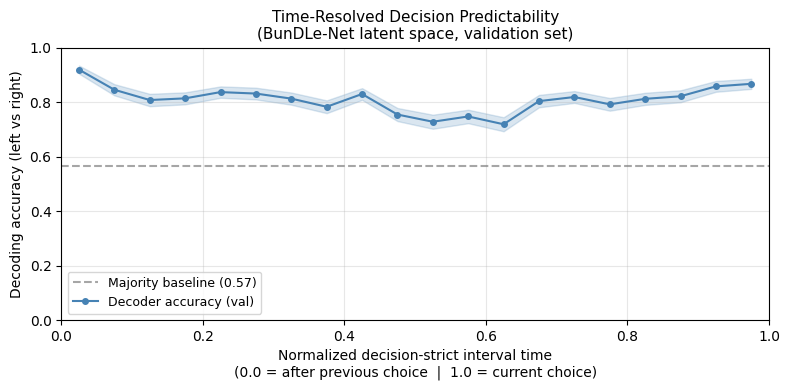

Saved -> /home/kerim/Projects/Neural Algorithms/NC-MCM/results/analysis/time_resolved_predictability_20260521_012643/accuracy_over_decision_strict_time.png


In [10]:
# Figure 1: accuracy vs normalised decision-strict interval time
N_BINS    = 20
bin_edges = np.linspace(0, 1, N_BINS + 1)
bin_ctrs  = (bin_edges[:-1] + bin_edges[1:]) / 2

bin_idx = pd.cut(df_val['normalized_time'], bins=bin_edges,
                 labels=False, include_lowest=True)

bin_acc, bin_sem, bin_n = [], [], []
for b_i in range(N_BINS):
    mask = bin_idx == b_i
    if not mask.any():
        bin_acc.append(np.nan); bin_sem.append(np.nan); bin_n.append(0)
    else:
        c = df_val['correct'].values[mask]
        bin_acc.append(c.mean())
        bin_sem.append(stats.sem(c))
        bin_n.append(mask.sum())

bin_acc = np.array(bin_acc)
bin_sem = np.array(bin_sem)
chance  = len(b_val[b_val == 1]) / len(b_val)   # majority-class baseline

fig, ax = plt.subplots(figsize=(8, 4))
ax.axhline(chance, color='grey', linestyle='--', alpha=0.7,
           label=f'Majority baseline ({chance:.2f})')
ax.fill_between(bin_ctrs, bin_acc - bin_sem, bin_acc + bin_sem,
                alpha=0.2, color='steelblue')
ax.plot(bin_ctrs, bin_acc, '-o', color='steelblue', markersize=4,
        label='Decoder accuracy (val)')
ax.set_xlabel(
    'Normalized decision-strict interval time\n'
    '(0.0 = after previous choice  |  1.0 = current choice)',
    fontsize=10
)
ax.set_ylabel('Decoding accuracy (left vs right)', fontsize=10)
ax.set_title(
    'Time-Resolved Decision Predictability\n'
    '(BunDLe-Net latent space, validation set)',
    fontsize=11
)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'accuracy_over_decision_strict_time.png', dpi=150)
plt.show()
print(f'Saved -> {OUTPUT_DIR / "accuracy_over_decision_strict_time.png"}')

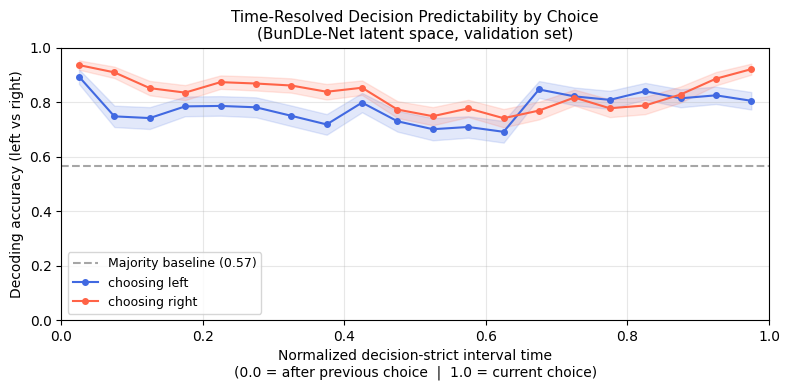

Saved -> /home/kerim/Projects/Neural Algorithms/NC-MCM/results/analysis/time_resolved_predictability_20260521_012643/accuracy_over_decision_strict_time_by_choice.png


In [11]:
# Figure 2: accuracy vs normalised time, split by choice
CHOICE_COLORS = {
    b_labels[0]: 'royalblue',
    b_labels[1]: 'tomato',
}

fig, ax = plt.subplots(figsize=(8, 4))
ax.axhline(chance, color='grey', linestyle='--', alpha=0.7,
           label=f'Majority baseline ({chance:.2f})')

for choice_name, color in CHOICE_COLORS.items():
    sub     = df_val[df_val['choice_label'] == choice_name]
    sub_idx = pd.cut(sub['normalized_time'], bins=bin_edges,
                     labels=False, include_lowest=True)
    acc_c, sem_c = [], []
    for b_i in range(N_BINS):
        mask = sub_idx == b_i
        if not mask.any():
            acc_c.append(np.nan); sem_c.append(np.nan)
        else:
            c = sub['correct'].values[mask]
            acc_c.append(c.mean())
            sem_c.append(stats.sem(c))
    acc_c = np.array(acc_c)
    sem_c = np.array(sem_c)
    ax.fill_between(bin_ctrs, acc_c - sem_c, acc_c + sem_c,
                    alpha=0.15, color=color)
    ax.plot(bin_ctrs, acc_c, '-o', color=color, markersize=4,
            label=choice_name)

ax.set_xlabel(
    'Normalized decision-strict interval time\n'
    '(0.0 = after previous choice  |  1.0 = current choice)',
    fontsize=10
)
ax.set_ylabel('Decoding accuracy (left vs right)', fontsize=10)
ax.set_title(
    'Time-Resolved Decision Predictability by Choice\n'
    '(BunDLe-Net latent space, validation set)',
    fontsize=11
)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'accuracy_over_decision_strict_time_by_choice.png', dpi=150)
plt.show()
print(f'Saved -> {OUTPUT_DIR / "accuracy_over_decision_strict_time_by_choice.png"}')

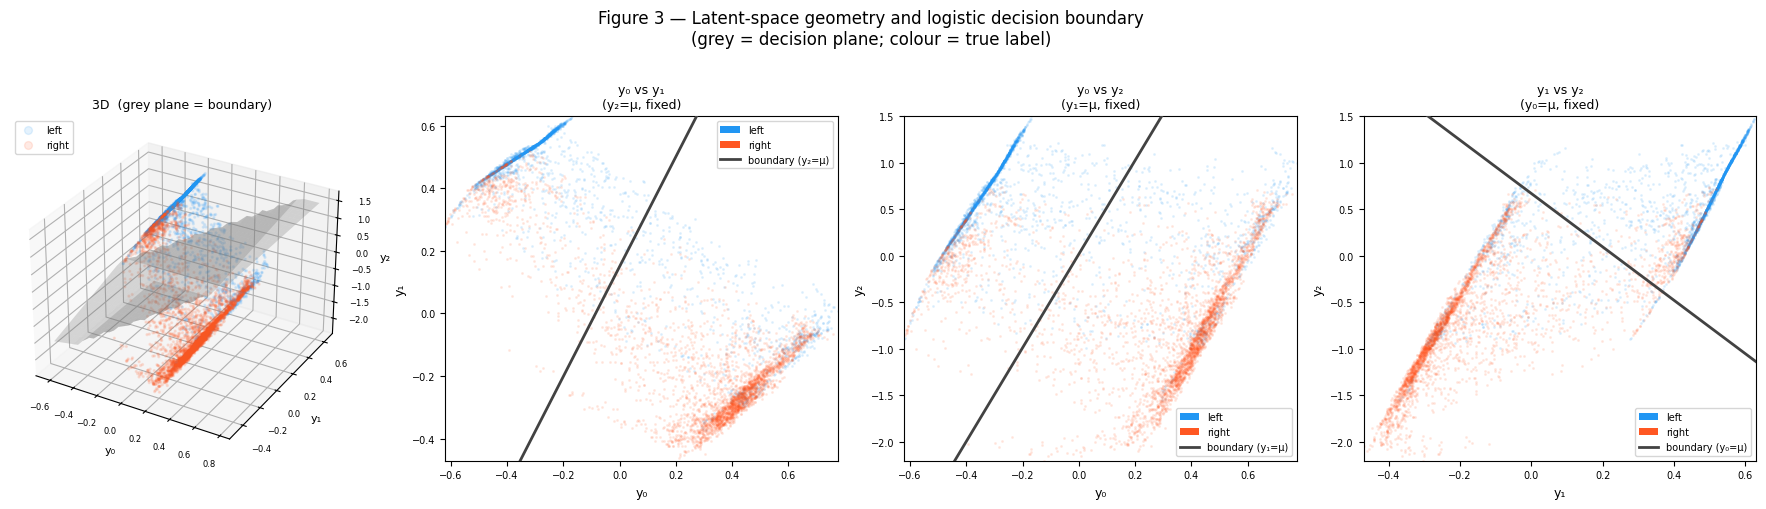

Saved: /home/kerim/Projects/Neural Algorithms/NC-MCM/results/analysis/time_resolved_predictability_20260521_012643/latent_space_decision_boundary.png


In [29]:
# ── Figure 3: Latent-space geometry + logistic decision boundary ──────────────
# 4-panel layout: [3D scatter + decision plane] + [3 × 2D projections]
# Points coloured by TRUE label (blue=left, orange=right);
# grey surface/line = logistic boundary (w·y + b = 0, fixing the 3rd dim at its
# mean for the 2D projections).

from mpl_toolkits.mplot3d import Axes3D   # registers '3d' projection

LAT_COLORS = {0: '#2196F3', 1: '#FF5722'}  # left=blue  right=orange-red
DIM_NAMES  = ['y₀', 'y₁', 'y₂']

w           = clf.coef_[0]          # shape (latent_dim,)
b_int       = clf.intercept_[0]     # scalar

# Raw arrays (validation set)
y_all  = lat_val                    # (N, 3)
lab_all = b_val                     # (N,)

fig = plt.figure(figsize=(18, 5))
fig.suptitle(
    'Figure 3 — Latent-space geometry and logistic decision boundary\n'
    '(grey = decision plane; colour = true label)',
    fontsize=12, y=1.01,
)

# ── 3D panel ──────────────────────────────────────────────────────────────────
ax3d = fig.add_subplot(1, 4, 1, projection='3d')
for lab in [0, 1]:
    m = lab_all == lab
    ax3d.scatter(y_all[m, 0], y_all[m, 1], y_all[m, 2],
                 c=LAT_COLORS[lab], alpha=0.12, s=2,
                 label=b_labels[lab].replace('choosing ', ''))

# Decision plane in (y0, y1) → solve for y2
grid_0 = np.linspace(y_all[:, 0].min(), y_all[:, 0].max(), 24)
grid_1 = np.linspace(y_all[:, 1].min(), y_all[:, 1].max(), 24)
G0, G1 = np.meshgrid(grid_0, grid_1)
if abs(w[2]) > 1e-8:
    G2 = -(b_int + w[0]*G0 + w[1]*G1) / w[2]
    G2 = np.clip(G2, y_all[:, 2].min(), y_all[:, 2].max())
    ax3d.plot_surface(G0, G1, G2, alpha=0.28, color='#9E9E9E', zorder=0)

ax3d.set_xlabel(DIM_NAMES[0], fontsize=8, labelpad=1)
ax3d.set_ylabel(DIM_NAMES[1], fontsize=8, labelpad=1)
ax3d.set_zlabel(DIM_NAMES[2], fontsize=8, labelpad=1)
ax3d.tick_params(labelsize=6)
ax3d.set_title('3D  (grey plane = boundary)', fontsize=9)
ax3d.legend(markerscale=4, fontsize=7, loc='upper left')

# ── 2D projections ────────────────────────────────────────────────────────────
# Each panel fixes the 3rd axis at its empirical mean
PROJECTIONS = [(0, 1, 2), (0, 2, 1), (1, 2, 0)]  # (x_ax, y_ax, fixed_ax)

from matplotlib.patches import Patch

for panel_idx, (xi, yi, fi) in enumerate(PROJECTIONS):
    ax = fig.add_subplot(1, 4, panel_idx + 2)

    for lab in [0, 1]:
        m = lab_all == lab
        ax.scatter(y_all[m, xi], y_all[m, yi],
                   c=LAT_COLORS[lab], alpha=0.09, s=1.5, rasterized=True)

    # Decision line: w[xi]*x + w[yi]*y + w[fi]*mean_f + b_int = 0
    mean_f  = float(y_all[:, fi].mean())
    x_line  = np.linspace(y_all[:, xi].min(), y_all[:, xi].max(), 300)
    if abs(w[yi]) > 1e-8:
        y_line  = -(w[xi]*x_line + w[fi]*mean_f + b_int) / w[yi]
        ax.plot(x_line, y_line, color='#424242', lw=2,
                label=f'boundary ({DIM_NAMES[fi]}=μ)', zorder=5)

    ax.set_xlim(y_all[:, xi].min(), y_all[:, xi].max())
    ax.set_ylim(y_all[:, yi].min(), y_all[:, yi].max())
    ax.set_xlabel(DIM_NAMES[xi], fontsize=9)
    ax.set_ylabel(DIM_NAMES[yi], fontsize=9)
    ax.set_title(f'{DIM_NAMES[xi]} vs {DIM_NAMES[yi]}\n({DIM_NAMES[fi]}=μ, fixed)',
                 fontsize=9)
    ax.tick_params(labelsize=7)

    legend_elements = [
        Patch(facecolor=LAT_COLORS[l],
              label=b_labels[l].replace('choosing ', ''))
        for l in [0, 1]
    ] + [plt.Line2D([0], [0], color='#424242', lw=2,
                    label=f'boundary ({DIM_NAMES[fi]}=μ)')]
    ax.legend(handles=legend_elements, fontsize=7)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'latent_space_decision_boundary.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {OUTPUT_DIR / 'latent_space_decision_boundary.png'}")

In [12]:
# Save prediction table
save_cols = ['trial_id', 'within_trial_idx', 'normalized_time',
             'label', 'choice_label', 'correct', 'pred', 'p_class0', 'p_class1']
if 'hgf' in df_val.columns:
    save_cols.append('hgf')
df_val[save_cols].to_csv(OUTPUT_DIR / 'validation_prediction_table.csv', index=False)

# Save summary JSON
summary = {
    'run_dir':          str(RUN_DIR),
    'b_type':           config['b_type'],
    'b_mode':           config['b_mode'],
    'timestamp':        _ts,
    'n_train_windows':  int(len(b_train)),
    'n_val_windows':    int(len(b_val)),
    'n_train_trials':   int(n_train_trials),
    'n_val_trials':     int(n_val_trials),
    'n_run_trials':     int(n_run_trials),
    'val_acc':          float(val_acc),
    'val_balanced_acc': float(val_bal_acc),
    'ref_val_acc':      float(ref_acc),
    'b_labels':         b_labels,
    'val_label_dist':   {
        str(int(v)): int(c)
        for v, c in zip(*np.unique(b_val, return_counts=True))
    },
    'n_time_bins':      N_BINS,
}
with open(OUTPUT_DIR / 'summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print(f'Outputs saved to: {OUTPUT_DIR}')
for name in ['accuracy_over_decision_strict_time.png',
             'accuracy_over_decision_strict_time_by_choice.png',
             'validation_prediction_table.csv',
             'summary.json']:
    print(f'  {name}')

Outputs saved to: /home/kerim/Projects/Neural Algorithms/NC-MCM/results/analysis/time_resolved_predictability_20260521_012643
  accuracy_over_decision_strict_time.png
  accuracy_over_decision_strict_time_by_choice.png
  validation_prediction_table.csv
  summary.json


## Phase 6 — Trial / `metrics.json` alignment diagnostic

Compare the 237 run trials (`trial_start_indices.npy`) with the 258 entries in
`metrics.json`. The run trial IDs span `[0, 236]` but `metrics.json` has 258 entries;
some behavioral trials were not covered by the neural recording.

**Rule**: the 237 run trial IDs are **not** assumed to be the first 237 entries of
`metrics.json`. Identity mapping (`trial_id == metrics_index`) is treated as a
hypothesis and verified by checking temporal ordering consistency.

In [15]:
import sys
sys.path.insert(0, str(REPO_ROOT))
from ncmcm.data_loaders.bandit_task import BanditTaskNeuroPixelsDataset

# Load the dataset (uses cached pickle — fast if already processed)
ds = BanditTaskNeuroPixelsDataset(
    str(DATASET_PATH),
    downsample_fs=config.get('downsample_fs', 30),
    downsample_method=config.get('downsample_method', 'gaussian'),
    good_neurons_only=config.get('good_neurons_only', False),
    b_mode=config.get('b_mode', 'decision_strict'),
    hgf_model='binary2',
    hgf_column='x_1_expected_mean',
)
print(f'Dataset loaded: x.shape={ds.x.shape},  T={ds.behavioral_time.shape[0]}')

METRICS_PATH = DATASET_PATH / 'metrics.json'
with open(METRICS_PATH) as f:
    metrics_data = json.load(f)
raw_trials = metrics_data.get('metrics', metrics_data).get('trials', [])

# Run trial IDs (the trials actually used in the BunDLe-Net run)
run_trial_ids = sorted(
    set(int(x) for x in tid_train) | set(int(x) for x in tid_val)
)

print('=== Trial count summary ===')
print(f'  trial_start_indices.npy entries:  {len(trial_start_indices)}')
print(f'  metrics.json trials:              {len(raw_trials)}')
print(f'  run trial IDs used:               {len(run_trial_ids)}')
print(f'    range: [{run_trial_ids[0]}, {run_trial_ids[-1]}]')
print(f'    contiguous [0..{len(run_trial_ids)-1}]: '
      f'{run_trial_ids == list(range(len(run_trial_ids)))}')
print()

n_extra = len(raw_trials) - len(trial_start_indices)
if n_extra > 0:
    print(f'metrics.json has {n_extra} more entries than trial_start_indices.')
    print('These extra behavioral trials likely fall outside the neural recording window.')
elif n_extra == 0:
    print('trial_start_indices and metrics.json have equal length.')
else:
    print(f'!! trial_start_indices has {-n_extra} MORE entries than metrics.json. Unexpected.')

print()
all_in_bounds = max(run_trial_ids) < len(raw_trials)
print(f'All run_trial_ids within metrics.json bounds: {all_in_bounds}')
if not all_in_bounds:
    oob = [i for i in run_trial_ids if i >= len(raw_trials)]
    print(f'  Out-of-bounds IDs: {oob[:10]} ...')

Loading dataset from cache: /home/kerim/Projects/Neural Algorithms/NC-MCM/datasets/raw/twoArmBandit/JPAS_0023_20230922/BanditTaskNeuroPixelsDataset/fs30_gaussian_all_normNone_267501d4.pkl
Successfully loaded cached dataset
Neuronal data shape: (575, 38794), Behavioral data shape: (1, 38794), Sampling frequency: 29.999289864765036 Hz
Behavioral labels: {0: 'choosing left', 1: 'choosing right'}
Dataset loaded: x.shape=(575, 38794),  T=38794
=== Trial count summary ===
  trial_start_indices.npy entries:  237
  metrics.json trials:              258
  run trial IDs used:               237
    range: [0, 236]
    contiguous [0..236]: True

metrics.json has 21 more entries than trial_start_indices.
These extra behavioral trials likely fall outside the neural recording window.

All run_trial_ids within metrics.json bounds: True


In [16]:
# ── Phase 6b: time-based identity-mapping check ─────────────────────────────
# ds already loaded in Phase 6a above; behavioral_time is the trimmed ms array
behavioral_time = ds.behavioral_time          # ms, shape (T,)
ds_trial_indices = ds.trial_indices           # per-sample trial index (0..N-1 or -1)

# ── Step 1: look up the metrics trial index for each dataset trial ────────────
# _create_trial_indices assigns a metrics-sorted index to each neural sample;
# _build_trial_start_indices just records WHERE each trial starts (ignores value).
# So: metrics_idx_k = ds.trial_indices[trial_start_indices[k]]
# is the exact sorted-trials position that the dataset uses for trial k.
metrics_idx_for_k = ds_trial_indices[trial_start_indices[run_trial_ids]]  # shape (237,)

print("=== Phase 6b: exact metrics-trial mapping ===")
print(f"trial_start_indices (first 5): {trial_start_indices[:5].tolist()}")
print(f"metrics_idx_for_k  (first 5): {metrics_idx_for_k[:5].tolist()}")
print(f"metrics_idx_for_k range: [{metrics_idx_for_k.min()}, {metrics_idx_for_k.max()}]")

# Check if identity mapping holds (metrics_idx_for_k[i] == run_trial_ids[i])
identity_ok = bool(np.all(metrics_idx_for_k == np.array(run_trial_ids)))
print(f"\nIdentity mapping (metrics_idx == run_trial_id)? {identity_ok}")
if not identity_ok:
    mismatches = np.where(metrics_idx_for_k != np.array(run_trial_ids))[0]
    print(f"  {len(mismatches)} mismatches; first 10:")
    for i in mismatches[:10]:
        print(f"    dataset trial {run_trial_ids[i]}  →  metrics_idx {metrics_idx_for_k[i]}")

# ── Step 2: build aligned offset using exact mapping ─────────────────────────
# Sort all metrics trials exactly as _create_trial_indices does
sorted_all_trials = sorted(raw_trials, key=lambda t: t.get('start', 0))
print(f"\nsorted_all_trials length (all, incl. start=None): {len(sorted_all_trials)}")

# For each dataset trial k, get the correct metrics start time
correct_start_ms = []
valid_mask = []
for k_pos, mi in enumerate(metrics_idx_for_k):
    t = sorted_all_trials[mi]
    s = t.get('start')
    if s is not None:
        correct_start_ms.append(float(s))
        valid_mask.append(True)
    else:
        correct_start_ms.append(np.nan)
        valid_mask.append(False)
correct_start_ms = np.array(correct_start_ms)
valid_mask       = np.array(valid_mask)

n_no_start = int((~valid_mask).sum())
if n_no_start:
    print(f"⚠  {n_no_start} dataset trials map to metrics entries with start=None — excluded from offset check.")

run_beh_ms = behavioral_time[trial_start_indices[run_trial_ids]]
offsets = correct_start_ms[valid_mask] - run_beh_ms[valid_mask]

median_offset = float(np.median(offsets))
mad_offset    = float(np.median(np.abs(offsets - median_offset)))
outlier_mask2 = np.abs(offsets - median_offset) > 3 * max(mad_offset, 1)
n_out2        = int(outlier_mask2.sum())

# Ordering check on inliers
inlier_sel = ~outlier_mask2
if inlier_sel.sum() > 1:
    inlier_beh = run_beh_ms[valid_mask][inlier_sel]
    inlier_raw = correct_start_ms[valid_mask][inlier_sel]
    order_ok   = bool(np.all(np.diff(inlier_beh) > 0) and np.all(np.diff(inlier_raw) > 0))
else:
    order_ok = True

print()
print("=== Time-based alignment check (exact mapping via ds.trial_indices) ===")
print("Method: behavioral_time[trial_start_indices[k]]  vs  sorted_all_trials[metrics_idx_for_k]['start']")
print(f"Offset (correct_raw_ms − behavioral_ms) — {offsets.size} valid trials:")
print(f"  mean:   {offsets.mean():8.1f} ms")
print(f"  std:    {offsets.std():8.1f} ms")
print(f"  median: {median_offset:8.1f} ms")
print(f"  MAD:    {mad_offset:8.1f} ms")
print(f"  min:    {offsets.min():8.1f} ms")
print(f"  max:    {offsets.max():8.1f} ms")
print(f"Outliers (|offset − median| > 3·MAD): {n_out2}")
if n_out2:
    out2_idx = np.where(outlier_mask2)[0][:10]
    rids2    = [run_trial_ids[i] for i in np.where(valid_mask)[0][out2_idx]]
    print(f"  Outlier run_trial_ids: {rids2}")
print(f"Temporal ordering preserved (inliers): {order_ok}")

# Preview
valid_indices_in_run = np.where(valid_mask)[0][:10]
preview = pd.DataFrame({
    "run_trial_id":  [run_trial_ids[i]            for i in valid_indices_in_run],
    "metrics_idx":   [int(metrics_idx_for_k[i])   for i in valid_indices_in_run],
    "behavioral_ms": run_beh_ms[valid_indices_in_run].round(0).astype(int),
    "raw_start_ms":  correct_start_ms[valid_indices_in_run].astype(int),
    "offset_ms":     (correct_start_ms[valid_indices_in_run] - run_beh_ms[valid_indices_in_run]).round(1),
    "raw_choice":    [sorted_all_trials[int(metrics_idx_for_k[i])].get("choice", "?")
                      for i in valid_indices_in_run],
})
print("\nPreview (first 10 valid run trials with exact mapping):")
print(preview.to_string(index=False))
print()

CONSISTENT = (mad_offset < 500) and (abs(median_offset) < 2000) and order_ok
if CONSISTENT:
    print("-> Identity mapping is CONSISTENT (after correct metrics-index lookup).")
    print(f"   Typical offset: {median_offset:.1f} ms (MAD={mad_offset:.1f} ms).")
    print("   The offset ≈ one downsampled frame (≤ 33 ms at 30 Hz) — as expected.")
    if n_out2:
        print(f"   {n_out2} outlier trial(s) — likely very short or anomalous trials.")
else:
    print("!! BLOCKER: Alignment NOT consistent even with exact mapping.")
    print(f"   Median offset={median_offset:.1f} ms, MAD={mad_offset:.1f} ms, order_ok={order_ok}.")
    print("   Do NOT use metrics.json annotations until alignment is clarified.")


=== Phase 6b: exact metrics-trial mapping ===
trial_start_indices (first 5): [0, 91, 318, 538, 788]
metrics_idx_for_k  (first 5): [0, 1, 2, 3, 4]
metrics_idx_for_k range: [0, 240]

Identity mapping (metrics_idx == run_trial_id)? False
  209 mismatches; first 10:
    dataset trial 28  →  metrics_idx 29
    dataset trial 29  →  metrics_idx 30
    dataset trial 30  →  metrics_idx 31
    dataset trial 31  →  metrics_idx 32
    dataset trial 32  →  metrics_idx 33
    dataset trial 33  →  metrics_idx 34
    dataset trial 34  →  metrics_idx 35
    dataset trial 35  →  metrics_idx 36
    dataset trial 36  →  metrics_idx 37
    dataset trial 37  →  metrics_idx 38

sorted_all_trials length (all, incl. start=None): 258

=== Time-based alignment check (exact mapping via ds.trial_indices) ===
Method: behavioral_time[trial_start_indices[k]]  vs  sorted_all_trials[metrics_idx_for_k]['start']
Offset (correct_raw_ms − behavioral_ms) — 237 valid trials:
  mean:      -16.5 ms
  std:         9.9 ms
  medi

## Phase 7 — Block Context & Previous Outcome Analyses

Using the verified `metrics_idx_for_k` alignment, we enrich `df_val` with contextual
metadata for each trial:

- **Block context**: which block type (better-left vs better-right) each trial belongs to,
  its position within the block, and whether the choice was congruent with the high-reward side.
- **Previous outcome**: whether the preceding trial was rewarded, and whether the animal
  stayed with the same choice or switched.

> **Sample-size caution (val set, 47 trials)**:  
> Block context: 23 better-left / 24 better-right — adequate for block-level contrasts.  
> Stay/switch: 38 stay / 9 switch — switch is rare; treat those curves as exploratory only.  
> Incongruent (outlier) choices per block may also be small — counts annotated in every plot.

**No source modules are modified.**

In [17]:
# ── Phase 7a: build per-trial metadata table ─────────────────────────────────
# Requires: sorted_all_trials, metrics_idx_for_k, run_trial_ids,
#           trial_start_indices, ds (loaded in Phase 6)

trial_meta_rows = []
for i, k in enumerate(run_trial_ids):
    mi   = int(metrics_idx_for_k[i])
    t    = sorted_all_trials[mi]
    samp = int(trial_start_indices[k])

    block_lbl = ds.block_labels[samp]          # 'better left' / 'better right'
    block_idx = int(ds.block_indices[samp])    # unique instance index (1–5)

    choice    = t.get('choice')                # 'l', 'r', or None
    rewarded  = t.get('rewarded')              # True / False / None
    probs     = t.get('set reward probabs l/r')

    # Derive better side from reward probabilities (robust, doesn't rely on block_lbl)
    if probs is not None:
        better_side = 'better left' if probs[0] > probs[1] else 'better right'
        congruent   = (choice == 'l' and better_side == 'better left') or \
                      (choice == 'r' and better_side == 'better right')
        congruent_label = 'congruent' if congruent else 'outlier'
    else:
        better_side     = block_lbl  # fallback: use dataset label
        congruent       = None
        congruent_label = None

    trial_meta_rows.append({
        'trial_id':         k,
        'metrics_idx':      mi,
        'block_label':      block_lbl,
        'block_idx':        block_idx,
        'better_side':      better_side,
        'choice':           choice,
        'rewarded':         rewarded,
        'congruent':        congruent,
        'congruent_label':  congruent_label,
    })

trial_meta_df = pd.DataFrame(trial_meta_rows)

# Add position within each block instance (0-based)
trial_meta_df['trial_pos_in_block'] = trial_meta_df.groupby('block_idx').cumcount()

# Previous-trial outcomes (session order preserved via run_trial_ids enumeration)
trial_meta_df['prev_rewarded'] = trial_meta_df['rewarded'].shift(1)
trial_meta_df['prev_choice']   = trial_meta_df['choice'].shift(1)
trial_meta_df['stay_switch']   = trial_meta_df.apply(
    lambda r: ('stay' if r['choice'] == r['prev_choice'] else 'switch')
              if pd.notna(r['prev_choice']) and r['choice'] is not None else np.nan,
    axis=1,
)

print(f'trial_meta_df shape: {trial_meta_df.shape}')
print(trial_meta_df[['trial_id','block_label','block_idx','better_side',
                       'choice','rewarded','congruent_label',
                       'trial_pos_in_block','stay_switch']].head(10).to_string(index=False))
print()

# Distributions (all 237 trials)
print('All-session distributions:')
print('  block_label:\n', trial_meta_df['block_label'].value_counts().to_string())
print('  better_side:\n', trial_meta_df['better_side'].value_counts().to_string())
print('  rewarded:   ', trial_meta_df['rewarded'].value_counts().to_dict())
print('  stay_switch:', trial_meta_df['stay_switch'].value_counts().to_dict())
print('  congruent_label:', trial_meta_df['congruent_label'].value_counts().to_dict())

trial_meta_df shape: (237, 13)
 trial_id block_label  block_idx better_side choice  rewarded congruent_label  trial_pos_in_block stay_switch
        0 better left          1 better left      r      True         outlier                   0         NaN
        1 better left          1 better left      r     False         outlier                   1        stay
        2 better left          1 better left      r     False         outlier                   2        stay
        3 better left          1 better left      l     False       congruent                   3      switch
        4 better left          1 better left      l      True       congruent                   4        stay
        5 better left          1 better left      l     False       congruent                   5        stay
        6 better left          1 better left      r     False         outlier                   6      switch
        7 better left          1 better left      r     False         outlier            

In [25]:
# ── Phase 7b: join trial metadata to df_val ──────────────────────────────────
# df_val contains only validation windows; trial_meta_df has all 237 trials.
# After merge, each window inherits the metadata of its parent trial.

META_COLS = ['trial_id', 'block_label', 'block_idx', 'better_side',
             'choice', 'rewarded', 'congruent_label',
             'trial_pos_in_block', 'stay_switch', 'prev_rewarded', 'prev_choice']

df_meta = df_val.merge(trial_meta_df[META_COLS], on='trial_id', how='left')

print(f'df_meta shape:  {df_meta.shape}  (df_val was {df_val.shape[0]} rows)')
print(f'Null counts in new columns:')
for c in META_COLS[1:]:
    n = df_meta[c].isna().sum()
    print(f'  {c:<25}: {n} nulls')

# Validation: expected counts per block type
val_block_counts = df_meta.drop_duplicates('trial_id')['better_side'].value_counts()
print(f'\nVal trials per block type: {val_block_counts.to_dict()}')
val_ss   = df_meta.drop_duplicates('trial_id')['stay_switch'].value_counts()
val_cong = df_meta.drop_duplicates('trial_id')['congruent_label'].value_counts()
print(f'Val stay/switch trials: {val_ss.to_dict()}')
print(f'Val congruent/outlier trials: {val_cong.to_dict()}')

df_meta shape:  (6210, 23)  (df_val was 6210 rows)
Null counts in new columns:
  block_label              : 0 nulls
  block_idx                : 0 nulls
  better_side              : 0 nulls
  choice                   : 0 nulls
  rewarded                 : 0 nulls
  congruent_label          : 0 nulls
  trial_pos_in_block       : 0 nulls
  stay_switch              : 0 nulls
  prev_rewarded            : 0 nulls
  prev_choice              : 0 nulls

Val trials per block type: {'better right': 24, 'better left': 23}
Val stay/switch trials: {'stay': 38, 'switch': 9}
Val congruent/outlier trials: {'congruent': 37, 'outlier': 10}


### Part C — Block Context Analyses

**C1** — Accuracy by block type (better-left vs better-right)  
**C2** — Accuracy as a function of trial position within block  
**C3** — Congruent vs outlier choices

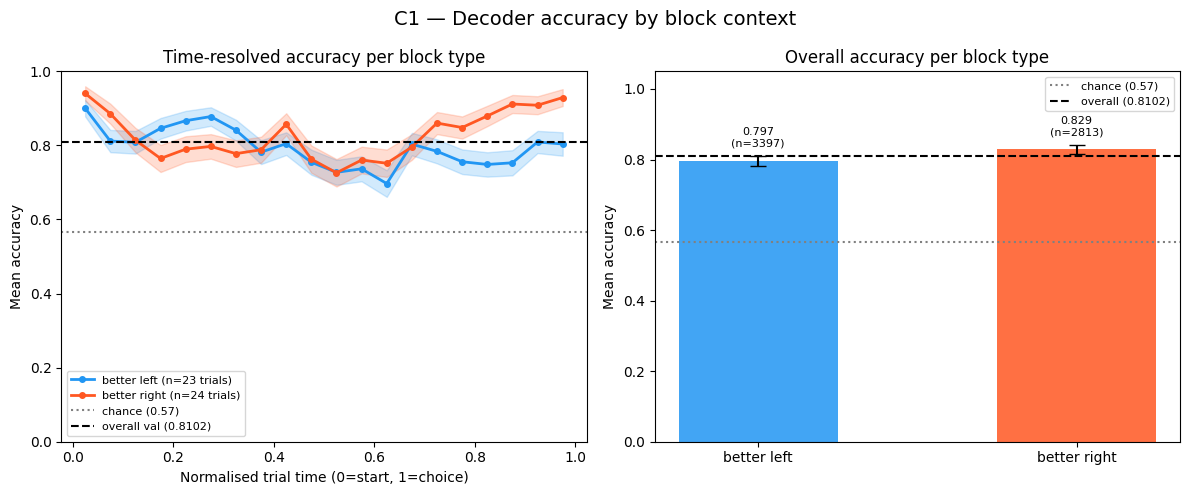

Saved: /home/kerim/Projects/Neural Algorithms/NC-MCM/results/analysis/time_resolved_predictability_20260521_012643/accuracy_by_block_context.png


In [19]:
# ── C1: Accuracy by block context (better-left vs better-right) ──────────────
BLOCK_PALETTE = {'better left': '#2196F3', 'better right': '#FF5722'}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('C1 — Decoder accuracy by block context', fontsize=14)

block_types = ['better left', 'better right']

# Left panel: time-resolved accuracy curves split by block type
for bt in block_types:
    sub  = df_meta[df_meta['better_side'] == bt]
    n_tr = sub['trial_id'].nunique()
    # Bin by normalized_time
    bin_acc, bin_se = [], []
    for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
        mask = (sub['normalized_time'] >= lo) & (sub['normalized_time'] < hi)
        vals = sub.loc[mask, 'correct']
        if len(vals) < 3:
            bin_acc.append(np.nan); bin_se.append(np.nan)
        else:
            bin_acc.append(vals.mean())
            bin_se.append(vals.std() / np.sqrt(len(vals)))
    bin_acc = np.array(bin_acc); bin_se = np.array(bin_se)
    axes[0].plot(bin_ctrs, bin_acc, '-o', color=BLOCK_PALETTE[bt],
                 label=f'{bt} (n={n_tr} trials)', linewidth=2, markersize=4)
    axes[0].fill_between(bin_ctrs, bin_acc - bin_se, bin_acc + bin_se,
                         color=BLOCK_PALETTE[bt], alpha=0.2)

axes[0].axhline(chance,  color='grey',  ls=':', lw=1.5, label=f'chance ({chance:.2f})')
axes[0].axhline(ref_acc, color='black', ls='--', lw=1.5,
                label=f'overall val ({ref_acc:.4f})')
axes[0].set_xlabel('Normalised trial time (0=start, 1=choice)')
axes[0].set_ylabel('Mean accuracy')
axes[0].set_title('Time-resolved accuracy per block type')
axes[0].legend(fontsize=8)
axes[0].set_ylim(0, 1)

# Right panel: overall accuracy + 95 % CI per block type
means, cis, labels_, counts_ = [], [], [], []
for bt in block_types:
    sub  = df_meta[df_meta['better_side'] == bt]['correct']
    n    = len(sub)
    mn   = sub.mean()
    se   = sub.std() / np.sqrt(n) if n > 1 else 0
    means.append(mn); cis.append(1.96 * se)
    labels_.append(bt); counts_.append(n)

x_pos = np.arange(len(block_types))
bars  = axes[1].bar(x_pos, means, color=[BLOCK_PALETTE[b] for b in block_types],
                    width=0.5, alpha=0.85, zorder=2)
axes[1].errorbar(x_pos, means, yerr=cis, fmt='none', color='black', capsize=6, zorder=3)
axes[1].axhline(chance,  color='grey',  ls=':', lw=1.5, label=f'chance ({chance:.2f})')
axes[1].axhline(ref_acc, color='black', ls='--', lw=1.5, label=f'overall ({ref_acc:.4f})')
for xi, (mn, n) in enumerate(zip(means, counts_)):
    axes[1].text(xi, mn + cis[xi] + 0.02, f'{mn:.3f}\n(n={n})',
                 ha='center', va='bottom', fontsize=8)
axes[1].set_xticks(x_pos); axes[1].set_xticklabels(block_types)
axes[1].set_ylabel('Mean accuracy'); axes[1].set_title('Overall accuracy per block type')
axes[1].set_ylim(0, 1.05); axes[1].legend(fontsize=8)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'accuracy_by_block_context.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {OUTPUT_DIR / 'accuracy_by_block_context.png'}")

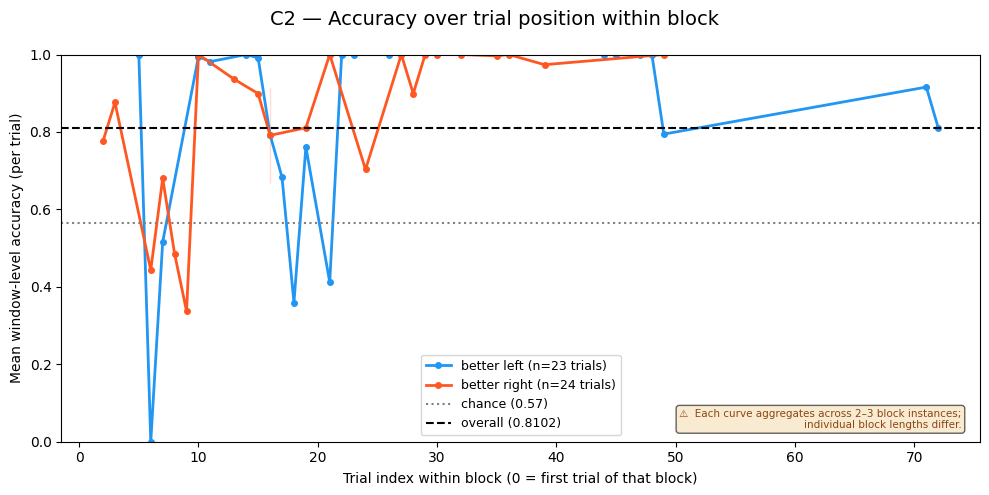

Saved: /home/kerim/Projects/Neural Algorithms/NC-MCM/results/analysis/time_resolved_predictability_20260521_012643/accuracy_over_block_position.png


In [20]:
# ── C2: Accuracy over trial position within block ─────────────────────────────
# x = trial_pos_in_block; aggregate windows per trial (mean correct),
# then plot vs block position, split by better_side.

# Aggregate to trial level
trial_level = (
    df_meta.groupby(['trial_id', 'better_side', 'block_idx', 'trial_pos_in_block'])
    ['correct'].mean().reset_index()
)
trial_level.rename(columns={'correct': 'mean_acc'}, inplace=True)

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('C2 — Accuracy over trial position within block', fontsize=14)

for bt in block_types:
    sub = trial_level[trial_level['better_side'] == bt].copy()
    if sub.empty:
        continue
    n_tr = len(sub)
    # Group by position across block instances
    pos_grp = sub.groupby('trial_pos_in_block')['mean_acc']
    pos_mn  = pos_grp.mean()
    pos_se  = pos_grp.std() / np.sqrt(pos_grp.count())
    ax.plot(pos_mn.index, pos_mn.values, '-o', color=BLOCK_PALETTE[bt],
            label=f'{bt} (n={n_tr} trials)', linewidth=2, markersize=4)
    ax.fill_between(pos_mn.index,
                    pos_mn.values - pos_se.values,
                    pos_mn.values + pos_se.values,
                    color=BLOCK_PALETTE[bt], alpha=0.2)

ax.axhline(chance,  color='grey',  ls=':', lw=1.5, label=f'chance ({chance:.2f})')
ax.axhline(ref_acc, color='black', ls='--', lw=1.5, label=f'overall ({ref_acc:.4f})')
ax.set_xlabel('Trial index within block (0 = first trial of that block)')
ax.set_ylabel('Mean window-level accuracy (per trial)')
ax.legend(fontsize=9); ax.set_ylim(0, 1)
ax.text(0.98, 0.03, '⚠  Each curve aggregates across 2–3 block instances;\n'
        'individual block lengths differ.', transform=ax.transAxes,
        ha='right', va='bottom', fontsize=7.5, color='saddlebrown',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.6))

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'accuracy_over_block_position.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {OUTPUT_DIR / 'accuracy_over_block_position.png'}")

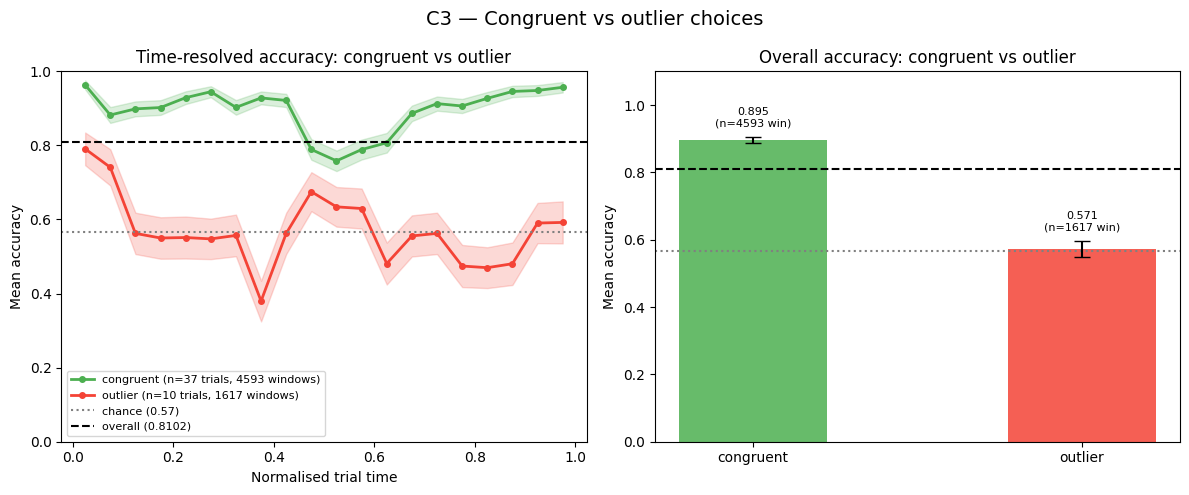

Saved: /home/kerim/Projects/Neural Algorithms/NC-MCM/results/analysis/time_resolved_predictability_20260521_012643/accuracy_congruent_vs_outlier.png


In [21]:
# ── C3: Congruent vs outlier choices ─────────────────────────────────────────
# "Congruent" = choice matches the high-reward side for that block
# "Outlier"   = choice opposite to high-reward side
# Sample sizes may be small for outlier — annotate counts on every bar.

CONG_PALETTE = {'congruent': '#4CAF50', 'outlier': '#F44336'}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('C3 — Congruent vs outlier choices', fontsize=14)

cong_types = ['congruent', 'outlier']

# Left: time-resolved curves
for cl in cong_types:
    sub  = df_meta[df_meta['congruent_label'] == cl]
    n_tr = sub['trial_id'].nunique()
    n_win = len(sub)
    bin_acc, bin_se = [], []
    for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
        mask = (sub['normalized_time'] >= lo) & (sub['normalized_time'] < hi)
        vals = sub.loc[mask, 'correct']
        if len(vals) < 3:
            bin_acc.append(np.nan); bin_se.append(np.nan)
        else:
            bin_acc.append(vals.mean())
            bin_se.append(vals.std() / np.sqrt(len(vals)))
    bin_acc = np.array(bin_acc); bin_se = np.array(bin_se)
    axes[0].plot(bin_ctrs, bin_acc, '-o', color=CONG_PALETTE[cl],
                 label=f'{cl} (n={n_tr} trials, {n_win} windows)',
                 linewidth=2, markersize=4)
    axes[0].fill_between(bin_ctrs, bin_acc - bin_se, bin_acc + bin_se,
                         color=CONG_PALETTE[cl], alpha=0.2)

axes[0].axhline(chance,  color='grey',  ls=':', lw=1.5, label=f'chance ({chance:.2f})')
axes[0].axhline(ref_acc, color='black', ls='--', lw=1.5, label=f'overall ({ref_acc:.4f})')
axes[0].set_xlabel('Normalised trial time'); axes[0].set_ylabel('Mean accuracy')
axes[0].set_title('Time-resolved accuracy: congruent vs outlier')
axes[0].legend(fontsize=8); axes[0].set_ylim(0, 1)

# Right: overall bar + counts
means_c, cis_c, counts_c = [], [], []
for cl in cong_types:
    sub = df_meta[df_meta['congruent_label'] == cl]['correct']
    n   = len(sub)
    mn  = sub.mean() if n > 0 else np.nan
    se  = sub.std() / np.sqrt(n) if n > 1 else 0
    means_c.append(mn); cis_c.append(1.96 * se); counts_c.append(n)

x_pos = np.arange(len(cong_types))
axes[1].bar(x_pos, means_c, color=[CONG_PALETTE[c] for c in cong_types],
            width=0.45, alpha=0.85, zorder=2)
axes[1].errorbar(x_pos, means_c, yerr=cis_c,
                 fmt='none', color='black', capsize=6, zorder=3)
axes[1].axhline(chance,  color='grey',  ls=':', lw=1.5)
axes[1].axhline(ref_acc, color='black', ls='--', lw=1.5)
for xi, (mn, ci, n) in enumerate(zip(means_c, cis_c, counts_c)):
    axes[1].text(xi, (mn or 0) + ci + 0.025, f'{(mn or 0):.3f}\n(n={n} win)',
                 ha='center', va='bottom', fontsize=8)
axes[1].set_xticks(x_pos); axes[1].set_xticklabels(cong_types)
axes[1].set_ylabel('Mean accuracy'); axes[1].set_title('Overall accuracy: congruent vs outlier')
axes[1].set_ylim(0, 1.1)

# Warn if outlier count is very small
n_outlier_trials = df_meta[df_meta['congruent_label'] == 'outlier']['trial_id'].nunique()
if n_outlier_trials < 10:
    axes[0].text(0.5, 0.97,
                 f'⚠  Only {n_outlier_trials} outlier trials — interpret with caution',
                 transform=axes[0].transAxes, ha='center', va='top',
                 fontsize=8, color='darkred',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='mistyrose', alpha=0.7))
    axes[1].text(0.5, 0.97,
                 f'⚠  Only {n_outlier_trials} outlier trials',
                 transform=axes[1].transAxes, ha='center', va='top',
                 fontsize=8, color='darkred',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='mistyrose', alpha=0.7))

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'accuracy_congruent_vs_outlier.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {OUTPUT_DIR / 'accuracy_congruent_vs_outlier.png'}")

### Part D — Previous Outcome Analyses

**D1** — Time-resolved accuracy split by previous trial rewarded vs not  
**D2** — Time-resolved accuracy split by stay vs switch  
**D3** — Previous × current choice accuracy matrix

> **Caution**: val-set trial counts for stay=38 / switch=9.  
> The switch curve is exploratory and should not be over-interpreted.

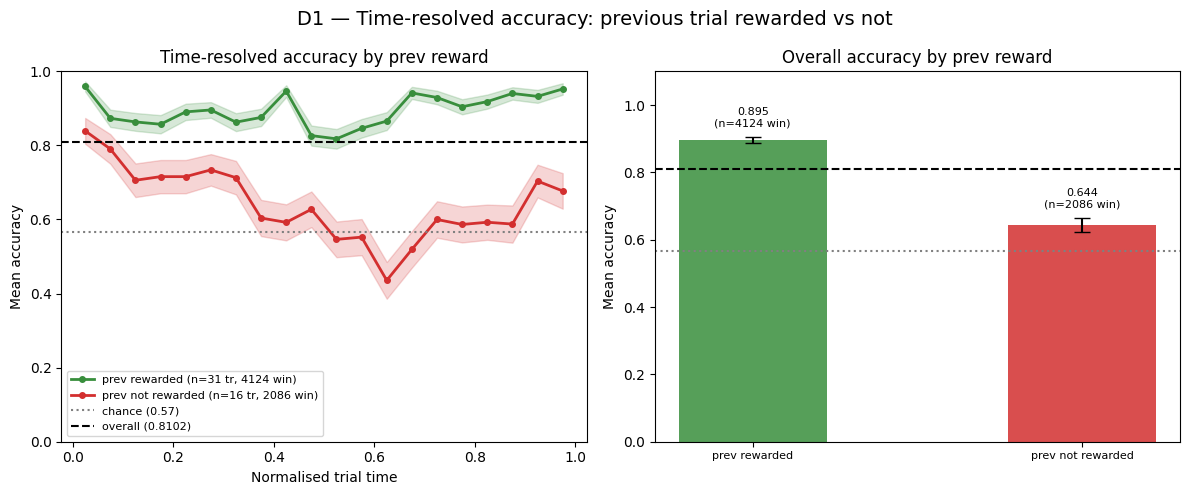

Saved: /home/kerim/Projects/Neural Algorithms/NC-MCM/results/analysis/time_resolved_predictability_20260521_012643/accuracy_over_time_by_previous_reward.png


In [22]:
# ── D1: Time-resolved accuracy split by previous reward ──────────────────────
REW_PALETTE = {True: '#388E3C', False: '#D32F2F'}
REW_LABELS  = {True: 'prev rewarded', False: 'prev not rewarded'}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('D1 — Time-resolved accuracy: previous trial rewarded vs not', fontsize=14)

rew_groups = [True, False]

for rw in rew_groups:
    sub  = df_meta[df_meta['prev_rewarded'] == rw]
    n_tr = sub['trial_id'].nunique()
    n_win = len(sub)
    bin_acc, bin_se = [], []
    for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
        mask = (sub['normalized_time'] >= lo) & (sub['normalized_time'] < hi)
        vals = sub.loc[mask, 'correct']
        if len(vals) < 3:
            bin_acc.append(np.nan); bin_se.append(np.nan)
        else:
            bin_acc.append(vals.mean())
            bin_se.append(vals.std() / np.sqrt(len(vals)))
    bin_acc = np.array(bin_acc); bin_se = np.array(bin_se)
    axes[0].plot(bin_ctrs, bin_acc, '-o', color=REW_PALETTE[rw],
                 label=f'{REW_LABELS[rw]} (n={n_tr} tr, {n_win} win)',
                 linewidth=2, markersize=4)
    axes[0].fill_between(bin_ctrs, bin_acc - bin_se, bin_acc + bin_se,
                         color=REW_PALETTE[rw], alpha=0.2)

axes[0].axhline(chance,  color='grey',  ls=':', lw=1.5, label=f'chance ({chance:.2f})')
axes[0].axhline(ref_acc, color='black', ls='--', lw=1.5, label=f'overall ({ref_acc:.4f})')
axes[0].set_xlabel('Normalised trial time'); axes[0].set_ylabel('Mean accuracy')
axes[0].set_title('Time-resolved accuracy by prev reward')
axes[0].legend(fontsize=8); axes[0].set_ylim(0, 1)

# Right: overall bar chart
means_r, cis_r, counts_r, lbls_r = [], [], [], []
for rw in rew_groups:
    sub = df_meta[df_meta['prev_rewarded'] == rw]['correct']
    n   = len(sub)
    mn  = sub.mean() if n > 0 else np.nan
    se  = sub.std() / np.sqrt(n) if n > 1 else 0
    means_r.append(mn); cis_r.append(1.96 * se); counts_r.append(n)
    lbls_r.append(REW_LABELS[rw])

x_pos = np.arange(len(rew_groups))
axes[1].bar(x_pos, means_r, color=[REW_PALETTE[rw] for rw in rew_groups],
            width=0.45, alpha=0.85, zorder=2)
axes[1].errorbar(x_pos, means_r, yerr=cis_r,
                 fmt='none', color='black', capsize=6, zorder=3)
axes[1].axhline(chance,  color='grey',  ls=':', lw=1.5)
axes[1].axhline(ref_acc, color='black', ls='--', lw=1.5)
for xi, (mn, ci, n) in enumerate(zip(means_r, cis_r, counts_r)):
    axes[1].text(xi, (mn or 0) + ci + 0.025, f'{(mn or 0):.3f}\n(n={n} win)',
                 ha='center', va='bottom', fontsize=8)
axes[1].set_xticks(x_pos); axes[1].set_xticklabels(lbls_r, fontsize=8)
axes[1].set_ylabel('Mean accuracy'); axes[1].set_title('Overall accuracy by prev reward')
axes[1].set_ylim(0, 1.1)

# Exclude windows where prev_rewarded is NaN (first trial of each split)
n_nan = df_meta['prev_rewarded'].isna().sum()
if n_nan > 0:
    axes[0].text(0.02, 0.03, f'{n_nan} windows excluded (no prev trial info)',
                 transform=axes[0].transAxes, fontsize=7.5, color='gray')

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'accuracy_over_time_by_previous_reward.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {OUTPUT_DIR / 'accuracy_over_time_by_previous_reward.png'}")

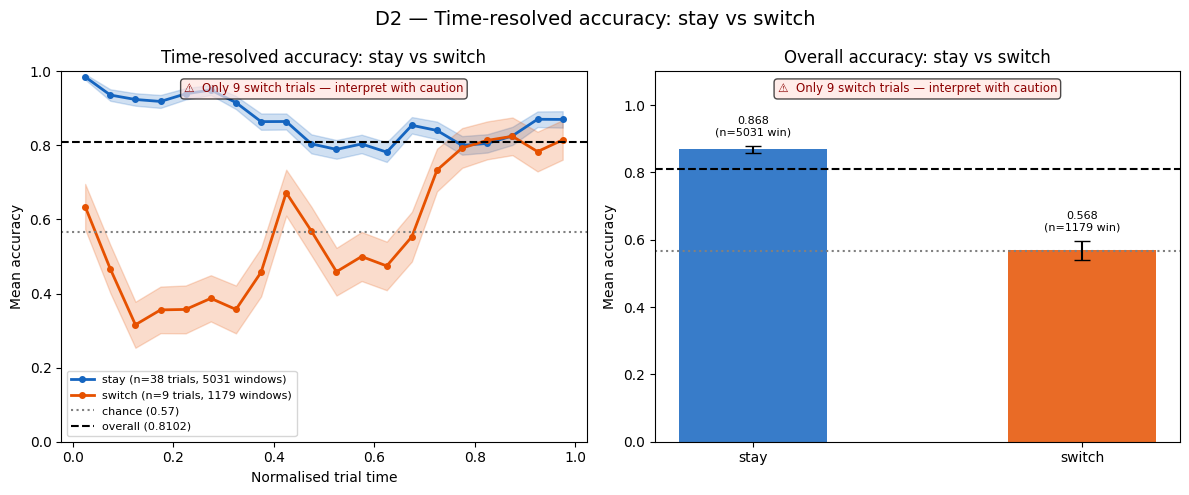

Saved: /home/kerim/Projects/Neural Algorithms/NC-MCM/results/analysis/time_resolved_predictability_20260521_012643/accuracy_over_time_stay_vs_switch.png


In [23]:
# ── D2: Time-resolved accuracy split by stay vs switch ───────────────────────
SS_PALETTE = {'stay': '#1565C0', 'switch': '#E65100'}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('D2 — Time-resolved accuracy: stay vs switch', fontsize=14)

ss_groups = ['stay', 'switch']

for ss in ss_groups:
    sub  = df_meta[df_meta['stay_switch'] == ss]
    n_tr = sub['trial_id'].nunique()
    n_win = len(sub)
    bin_acc, bin_se = [], []
    for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
        mask = (sub['normalized_time'] >= lo) & (sub['normalized_time'] < hi)
        vals = sub.loc[mask, 'correct']
        if len(vals) < 3:
            bin_acc.append(np.nan); bin_se.append(np.nan)
        else:
            bin_acc.append(vals.mean())
            bin_se.append(vals.std() / np.sqrt(len(vals)))
    bin_acc = np.array(bin_acc); bin_se = np.array(bin_se)
    axes[0].plot(bin_ctrs, bin_acc, '-o', color=SS_PALETTE[ss],
                 label=f'{ss} (n={n_tr} trials, {n_win} windows)',
                 linewidth=2, markersize=4)
    axes[0].fill_between(bin_ctrs, bin_acc - bin_se, bin_acc + bin_se,
                         color=SS_PALETTE[ss], alpha=0.2)

axes[0].axhline(chance,  color='grey',  ls=':', lw=1.5, label=f'chance ({chance:.2f})')
axes[0].axhline(ref_acc, color='black', ls='--', lw=1.5, label=f'overall ({ref_acc:.4f})')
axes[0].set_xlabel('Normalised trial time'); axes[0].set_ylabel('Mean accuracy')
axes[0].set_title('Time-resolved accuracy: stay vs switch')
axes[0].legend(fontsize=8); axes[0].set_ylim(0, 1)

# Warn about small switch count
n_switch_tr = df_meta[df_meta['stay_switch'] == 'switch']['trial_id'].nunique()
if n_switch_tr < 12:
    for ax in axes:
        ax.text(0.5, 0.97,
                f'⚠  Only {n_switch_tr} switch trials — interpret with caution',
                transform=ax.transAxes, ha='center', va='top', fontsize=8.5,
                color='darkred',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='mistyrose', alpha=0.7))

# Right panel: bar chart
means_s, cis_s, counts_s = [], [], []
for ss in ss_groups:
    sub = df_meta[df_meta['stay_switch'] == ss]['correct']
    n   = len(sub)
    mn  = sub.mean() if n > 0 else np.nan
    se  = sub.std() / np.sqrt(n) if n > 1 else 0
    means_s.append(mn); cis_s.append(1.96 * se); counts_s.append(n)

x_pos = np.arange(len(ss_groups))
axes[1].bar(x_pos, means_s, color=[SS_PALETTE[s] for s in ss_groups],
            width=0.45, alpha=0.85, zorder=2)
axes[1].errorbar(x_pos, means_s, yerr=cis_s,
                 fmt='none', color='black', capsize=6, zorder=3)
axes[1].axhline(chance,  color='grey',  ls=':', lw=1.5)
axes[1].axhline(ref_acc, color='black', ls='--', lw=1.5)
for xi, (mn, ci, n) in enumerate(zip(means_s, cis_s, counts_s)):
    axes[1].text(xi, (mn or 0) + ci + 0.025, f'{(mn or 0):.3f}\n(n={n} win)',
                 ha='center', va='bottom', fontsize=8)
axes[1].set_xticks(x_pos); axes[1].set_xticklabels(ss_groups)
axes[1].set_ylabel('Mean accuracy'); axes[1].set_title('Overall accuracy: stay vs switch')
axes[1].set_ylim(0, 1.1)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'accuracy_over_time_stay_vs_switch.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {OUTPUT_DIR / 'accuracy_over_time_stay_vs_switch.png'}")

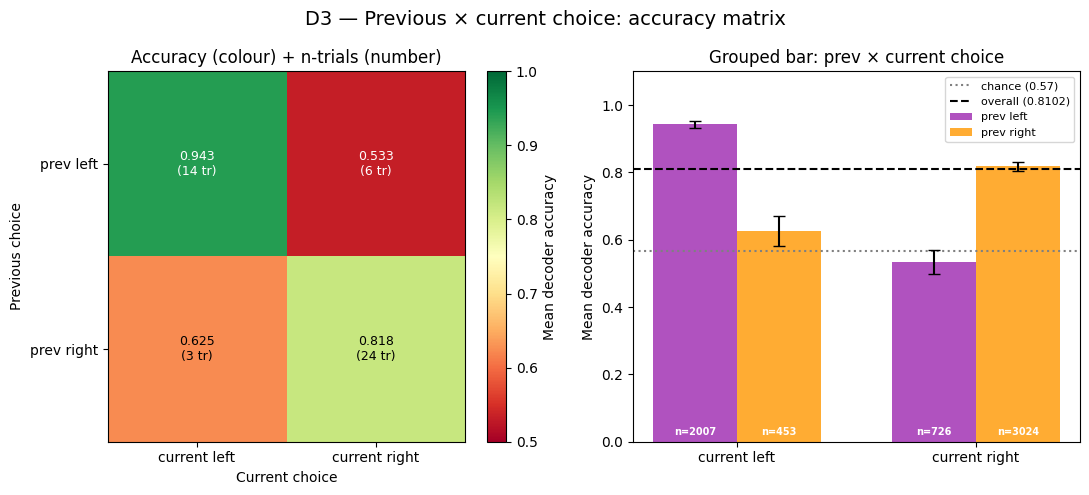

Saved: /home/kerim/Projects/Neural Algorithms/NC-MCM/results/analysis/time_resolved_predictability_20260521_012643/accuracy_previous_current_choice_matrix.png


In [26]:
# ── D3: Previous × current choice accuracy matrix ────────────────────────────
# 2×2: prev_choice (l/r) × current choice (l/r)
# Each cell: mean decoder accuracy (window-level) ± n

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
fig.suptitle('D3 — Previous × current choice: accuracy matrix', fontsize=14)

choices = ['l', 'r']
choice_lbl = {'l': 'left', 'r': 'right'}

# Build matrix of mean accuracy and n-trials
mat_acc   = np.full((2, 2), np.nan)
mat_ntr   = np.zeros((2, 2), dtype=int)
mat_nwin  = np.zeros((2, 2), dtype=int)

for pi, pc in enumerate(choices):
    for ci, cc in enumerate(choices):
        sub = df_meta[(df_meta['prev_choice'] == pc) & (df_meta['choice'] == cc)]
        n_tr = sub['trial_id'].nunique()
        n_win = len(sub)
        mat_ntr[pi, ci]  = n_tr
        mat_nwin[pi, ci] = n_win
        if n_win > 0:
            mat_acc[pi, ci] = sub['correct'].mean()

# Left: heatmap of accuracy
im = axes[0].imshow(mat_acc, cmap='RdYlGn', vmin=0.5, vmax=1.0, aspect='auto')
plt.colorbar(im, ax=axes[0], label='Mean decoder accuracy')
axes[0].set_xticks([0, 1]); axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['current left', 'current right'])
axes[0].set_yticklabels(['prev left', 'prev right'])
axes[0].set_xlabel('Current choice'); axes[0].set_ylabel('Previous choice')
axes[0].set_title('Accuracy (colour) + n-trials (number)')
for pi in range(2):
    for ci in range(2):
        acc_txt = f'{mat_acc[pi,ci]:.3f}' if not np.isnan(mat_acc[pi, ci]) else 'n/a'
        axes[0].text(ci, pi, f'{acc_txt}\n({mat_ntr[pi,ci]} tr)',
                     ha='center', va='center', fontsize=9,
                     color='black' if 0.6 <= mat_acc[pi,ci] <= 0.85 else 'white')

# Right: grouped bar chart
x_pos  = np.arange(2)
width  = 0.35
colors_prev = {'l': '#9C27B0', 'r': '#FF9800'}
for pi, pc in enumerate(choices):
    vals = [mat_acc[pi, ci] for ci in range(2)]
    errs = []
    for ci, cc in enumerate(choices):
        sub = df_meta[(df_meta['prev_choice'] == pc) & (df_meta['choice'] == cc)]['correct']
        se  = sub.std() / np.sqrt(len(sub)) if len(sub) > 1 else 0
        errs.append(1.96 * se)
    axes[1].bar(x_pos + pi * width - width/2, vals,
                width=width, alpha=0.8, color=colors_prev[pc],
                label=f'prev {choice_lbl[pc]}', zorder=2)
    axes[1].errorbar(x_pos + pi * width - width/2, vals,
                     yerr=errs, fmt='none', color='black', capsize=4, zorder=3)

axes[1].axhline(chance,  color='grey',  ls=':', lw=1.5, label=f'chance ({chance:.2f})')
axes[1].axhline(ref_acc, color='black', ls='--', lw=1.5, label=f'overall ({ref_acc:.4f})')
axes[1].set_xticks(x_pos); axes[1].set_xticklabels(['current left', 'current right'])
axes[1].set_ylabel('Mean decoder accuracy'); axes[1].set_title('Grouped bar: prev × current choice')
axes[1].legend(fontsize=8); axes[1].set_ylim(0, 1.1)

# Annotate n-windows
for pi, pc in enumerate(choices):
    for ci, cc in enumerate(choices):
        axes[1].text(ci + pi * width - width/2, 0.02,
                     f'n={mat_nwin[pi,ci]}',
                     ha='center', fontsize=7, color='white', fontweight='bold')

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'accuracy_previous_current_choice_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {OUTPUT_DIR / 'accuracy_previous_current_choice_matrix.png'}")

### Part E — Summary, Verification, and Cautions

In [28]:
# ── E: Save enriched CSV + extended summary.json + print report ──────────────
import os

# Save enriched validation predictions table
csv_path = OUTPUT_DIR / 'validation_prediction_table_with_metadata.csv'
df_meta.to_csv(csv_path, index=False)
print(f"Saved enriched CSV: {csv_path}")
print(f"  shape: {df_meta.shape}")

# ── Count actual generated figures (all from this OUTPUT_DIR) ─────────────────
expected_figures = [
    # Existing (Phases 5)
    'accuracy_over_decision_strict_time.png',
    'accuracy_over_decision_strict_time_by_choice.png',
    'latent_space_decision_boundary.png',
    # Phase 7 (new)
    'accuracy_by_block_context.png',
    'accuracy_over_block_position.png',
    'accuracy_congruent_vs_outlier.png',
    'accuracy_over_time_by_previous_reward.png',
    'accuracy_over_time_stay_vs_switch.png',
    'accuracy_previous_current_choice_matrix.png',
]
fig_status = {fn: (OUTPUT_DIR / fn).exists() for fn in expected_figures}

# ── Build numeric summaries ───────────────────────────────────────────────────
val_tids    = df_meta['trial_id'].unique()
block_cnts  = df_meta.drop_duplicates('trial_id')['better_side'].value_counts().to_dict()
rew_cnts    = df_meta.drop_duplicates('trial_id')['rewarded'].value_counts().to_dict()
ss_cnts     = df_meta.drop_duplicates('trial_id')['stay_switch'].value_counts().to_dict()
cong_cnts   = df_meta.drop_duplicates('trial_id')['congruent_label'].value_counts().to_dict()
block_acc   = df_meta.groupby('better_side')['correct'].mean().to_dict()
ss_acc      = df_meta.groupby('stay_switch')['correct'].mean().to_dict()
rew_acc     = df_meta.groupby('prev_rewarded')['correct'].mean().to_dict()
cong_acc    = df_meta.groupby('congruent_label')['correct'].mean().to_dict()

# ── Extended summary.json ─────────────────────────────────────────────────────
ext_summary = {
    'run_path':                 str(RUN_DIR),
    'dataset_path':             str(DATASET_PATH),
    'decoder_val_accuracy':     float(val_acc),
    'decoder_val_bal_accuracy': float(val_bal_acc),
    'reference_val_accuracy':   float(ref_acc),
    'chance_level':             float(chance),
    'n_val_windows':            int(len(df_meta)),
    'n_val_trials':             int(len(val_tids)),
    'metadata_alignment':       'CONSISTENT' if CONSISTENT else 'INCONSISTENT',
    'metrics_offset_median_ms': float(np.median(
        (correct_start_ms[valid_mask] - run_beh_ms[valid_mask])
    )) if 'correct_start_ms' in dir() else None,
    'block_metadata_available': True,
    'prev_outcome_metadata_available': True,
    'block_trial_counts_val':   {str(k): int(v) for k, v in block_cnts.items()},
    'rewarded_trial_counts_val': {str(k): int(v) for k, v in rew_cnts.items()},
    'stay_switch_trial_counts_val': {str(k): int(v) for k, v in ss_cnts.items()},
    'congruent_trial_counts_val': {str(k): int(v) for k, v in cong_cnts.items()},
    'mean_accuracy_by_block': {str(k): round(float(v), 4) for k, v in block_acc.items()},
    'mean_accuracy_by_stay_switch': {str(k): round(float(v), 4) for k, v in ss_acc.items()},
    'mean_accuracy_by_prev_rewarded': {str(k): round(float(v), 4) for k, v in rew_acc.items()},
    'mean_accuracy_by_congruence': {str(k): round(float(v), 4) for k, v in cong_acc.items()},
    'figures': fig_status,
}

summary_path = OUTPUT_DIR / 'summary.json'
with open(summary_path, 'w') as f:
    json.dump(ext_summary, f, indent=2)
print(f"\nSaved extended summary: {summary_path}")

# ── Print concise report ──────────────────────────────────────────────────────
sep = '─' * 60
print(f'\n{sep}')
print('PHASE 7 ANALYSIS REPORT')
print(sep)

print(f'\nDecoder accuracy:  val={val_acc:.4f}  (reference={ref_acc:.4f},  chance={chance:.2f})')
print(f'Val set:           {len(val_tids)} trials,  {len(df_meta)} windows')

print(f'\nFigures created ({sum(fig_status.values())}/{len(fig_status)}):')
for fn, ok in fig_status.items():
    status = '✓' if ok else '✗ MISSING'
    print(f'  [{status}] {fn}')

print(f'\nBlock context analyses (C1–C3):  AVAILABLE')
print(f'  better left:  {block_cnts.get("better left",0)} trials,  '
      f'acc={block_acc.get("better left",float("nan")):.4f}')
print(f'  better right: {block_cnts.get("better right",0)} trials,  '
      f'acc={block_acc.get("better right",float("nan")):.4f}')

print(f'\nPrevious outcome analyses (D1–D3):  AVAILABLE')
print(f'  prev rewarded:     {rew_cnts.get(True, rew_cnts.get("True", 0))} trials,  '
      f'acc={rew_acc.get(True, rew_acc.get("True", float("nan"))):.4f}')
print(f'  prev not rewarded: {rew_cnts.get(False, rew_cnts.get("False", 0))} trials,  '
      f'acc={rew_acc.get(False, rew_acc.get("False", float("nan"))):.4f}')
print(f'  stay:   {ss_cnts.get("stay",0)} trials,  acc={ss_acc.get("stay",float("nan")):.4f}')
print(f'  switch: {ss_cnts.get("switch",0)} trials,  acc={ss_acc.get("switch",float("nan")):.4f}')

print(f'\nCongruence analysis (C3):')
print(f'  congruent: {cong_cnts.get("congruent",0)} trials,  acc={cong_acc.get("congruent",float("nan")):.4f}')
print(f'  outlier:   {cong_cnts.get("outlier",0)} trials,  acc={cong_acc.get("outlier",float("nan")):.4f}')

# ── Sample-size warnings ──────────────────────────────────────────────────────
print(f'\nSample-size warnings:')
n_switch = ss_cnts.get('switch', 0)
if n_switch < 15:
    print(f'  ⚠  SWITCH trials: only {n_switch} in val — D2 switch curve exploratory only.')
n_outlier = cong_cnts.get('outlier', 0)
if n_outlier < 10:
    print(f'  ⚠  OUTLIER choices: only {n_outlier} val trials — C3 outlier bar exploratory.')
n_prev_norew = rew_cnts.get(False, rew_cnts.get('False', 0))
if n_prev_norew < 10:
    print(f'  ⚠  PREV NOT REWARDED: only {n_prev_norew} val trials — D1 curve sparse.')
print(f'\nNote: all analyses are observational associations, not causal claims.')

# ── Verify enriched CSV ───────────────────────────────────────────────────────
print(f'\nvalidation_prediction_table_with_metadata.csv: '
      f'{"EXISTS" if csv_path.exists() else "MISSING"}')

# ── git status --short ────────────────────────────────────────────────────────
import subprocess
result = subprocess.run(['git', 'status', '--short'], capture_output=True, text=True,
                       cwd=str(REPO_ROOT))
print(f'\ngit status --short:\n{result.stdout}')
print(sep)
print('No source modules were edited in this notebook.')

Saved enriched CSV: /home/kerim/Projects/Neural Algorithms/NC-MCM/results/analysis/time_resolved_predictability_20260521_012643/validation_prediction_table_with_metadata.csv
  shape: (6210, 23)

Saved extended summary: /home/kerim/Projects/Neural Algorithms/NC-MCM/results/analysis/time_resolved_predictability_20260521_012643/summary.json

────────────────────────────────────────────────────────────
PHASE 7 ANALYSIS REPORT
────────────────────────────────────────────────────────────

Decoder accuracy:  val=0.8111  (reference=0.8102,  chance=0.57)
Val set:           47 trials,  6210 windows

Figures created (8/8):
  [✓] accuracy_over_decision_strict_time.png
  [✓] accuracy_over_decision_strict_time_by_choice.png
  [✓] accuracy_by_block_context.png
  [✓] accuracy_over_block_position.png
  [✓] accuracy_congruent_vs_outlier.png
  [✓] accuracy_over_time_by_previous_reward.png
  [✓] accuracy_over_time_stay_vs_switch.png
  [✓] accuracy_previous_current_choice_matrix.png

Block context analyses

## Part F — Decision-Boundary Margin Analysis for Outlier & Switch Trials

> **Question**: Are outlier/switch choices hard to decode because they lie *close to the decision boundary* (uncertain / near-chance confidence), or because they are *confidently mapped to the wrong class* (block-favoured or previous-choice side)?

**Method**: for each validation window $i$ compute:

$$d_i = \frac{\mathbf{y}_i \cdot \mathbf{w} + b}{\|\mathbf{w}\|}, \qquad m_i = d_i \cdot (2\ell_i - 1)$$

where $\ell_i \in \{0,1\}$ is the true label and $(\mathbf{w}, b)$ are the logistic-regression weights.
- $m_i > 0$: latent point is on the **correct** side of the boundary  
- $m_i < 0$: latent point is on the **wrong** side  
- $|m_i|$ = distance from boundary (proxy for decoder confidence)

**Caveats**: outlier $n_{\text{val}}=10$, switch $n_{\text{val}}=9$ — all figures are exploratory.

In [ ]:
# ── F1: Compute signed distance & class-relative margin ───────────────────────
import numpy as np

# Decoder weights (available from Phase 3; reload-safe)
w_f1    = clf.coef_[0]        # (3,)
b_f1    = clf.intercept_[0]   # scalar
norm_w  = np.linalg.norm(w_f1)

Y = df_meta[['y0', 'y1', 'y2']].values
signed_dist  = (Y @ w_f1 + b_f1) / norm_w   # d_i: >0 → pred class 1 (right)
label_sign   = (2 * df_meta['label'].values - 1)  # +1 for class 1, -1 for class 0
class_margin = signed_dist * label_sign            # m_i: >0 ↔ correct side

df_meta = df_meta.copy()
df_meta['signed_dist']  = signed_dist
df_meta['class_margin'] = class_margin
df_meta['abs_margin']   = np.abs(class_margin)

# ── Sanity check: m > 0  ↔  correct (exact for logistic at threshold 0.5) ────
m_frac_correct = (class_margin > 0).mean()
print(f"frac(class_margin > 0) = {m_frac_correct:.4f}  vs  val_acc = {val_acc:.4f}")
assert abs(m_frac_correct - val_acc) < 1e-4, "Margin-accuracy mismatch!"
print("Sanity check ✓\n")

# ── Per-group statistics ──────────────────────────────────────────────────────
sep = '─' * 70
print(sep)
print(f"{'Group':<24} {'n_win':>5}  {'mean_m':>8}  {'median_|m|':>10}  {'frac_correct':>12}")
print(sep)
for col, groups in [
    ('congruent_label', ['congruent', 'outlier']),
    ('stay_switch',     ['stay',      'switch']),
    ('prev_rewarded',   [True,        False]),
]:
    for g in groups:
        sub = df_meta[df_meta[col] == g]
        n_tr = sub.drop_duplicates('trial_id').shape[0]
        mean_m   = sub['class_margin'].mean()
        med_absm = sub['abs_margin'].median()
        frac_c   = sub['correct'].mean()
        print(f"  {str(g):<22} {len(sub):>5d}  {mean_m:>+8.3f}  {med_absm:>10.3f}  {frac_c:>12.3f}  (n_trials={n_tr})")
print(sep)

In [ ]:
# ── F2: Margin-distribution figure — congruent/outlier, stay/switch ───────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
fig.suptitle('Class-Relative Margin  $m = d \\cdot (2\\ell - 1)$  by Group',
             fontsize=13, fontweight='bold')

BW      = 0.12
X_RANGE = np.linspace(-5, 5, 500)

def _plot_kde_group(ax, col, groups, palette, title):
    for grp, color in zip(groups, palette):
        sub = df_meta[df_meta[col] == grp]['class_margin'].values
        n_tr = int(df_meta[df_meta[col] == grp].drop_duplicates('trial_id').shape[0])
        if len(sub) < 5:
            continue
        kde = gaussian_kde(sub, bw_method=BW)
        yd  = kde(X_RANGE)
        ax.fill_between(X_RANGE, yd, alpha=0.25, color=color)
        ax.plot(X_RANGE, yd, color=color, lw=2.0,
                label=f'{grp}  (n_tr={n_tr})')
        ax.axvline(sub.mean(), color=color, ls='--', lw=1.3, alpha=0.8)
    ax.axvline(0, color='black', ls='-', lw=1.5, alpha=0.35)
    ax.text(0.03, 0.97, '← wrong side', ha='left', va='top',
            transform=ax.transAxes, fontsize=9, color='#757575')
    ax.text(0.97, 0.97, 'correct side →', ha='right', va='top',
            transform=ax.transAxes, fontsize=9, color='#757575')
    ax.set_xlabel('Class-relative margin  $m$', fontsize=11)
    ax.set_ylabel('Density', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(fontsize=9, loc='upper left', bbox_to_anchor=(0.03, 0.87))
    ax.set_xlim(-5, 5)

_plot_kde_group(axes[0], 'congruent_label', ['congruent', 'outlier'],
                [CONG_PALETTE['congruent'], CONG_PALETTE['outlier']],
                'Congruent vs Outlier choices')
_plot_kde_group(axes[1], 'stay_switch', ['stay', 'switch'],
                [SS_PALETTE['stay'], SS_PALETTE['switch']],
                'Stay vs Switch choices')

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'margin_distributions_by_group.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {OUTPUT_DIR / 'margin_distributions_by_group.png'}")

In [ ]:
# ── F3: Accuracy vs |margin| bins + per-trial scatter ─────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
fig.suptitle('Accuracy vs. Boundary Distance', fontsize=13, fontweight='bold')

# ── Left: accuracy in |margin| decile bins (all val windows) ─────────────────
abs_m    = df_meta['abs_margin'].values
q_edges  = np.quantile(abs_m, np.linspace(0, 1, 11))
q_edges[-1] += 1e-8
bin_idx  = np.digitize(abs_m, q_edges[1:])     # 0-indexed bin
bin_acc  = [df_meta['correct'].values[bin_idx == b].mean() for b in range(10)]
bin_ctrs = [(q_edges[b] + q_edges[b+1]) / 2    for b in range(10)]
bin_n    = [(bin_idx == b).sum()                for b in range(10)]

ax = axes[0]
bars = ax.bar(bin_ctrs, bin_acc, width=np.diff(q_edges) * 0.8,
              color='#78909C', align='center', label='Decile acc')
ax.axhline(val_acc, color='#1565C0', ls='--', lw=1.5, label=f'Overall={val_acc:.3f}')
ax.axhline(chance,  color='gray',    ls=':',  lw=1.2, label=f'Chance={chance:.3f}')
for bar, n in zip(bars, bin_n):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            str(n), ha='center', va='bottom', fontsize=7)
ax.set_xlabel('|class-relative margin| decile midpoint', fontsize=10)
ax.set_ylabel('Accuracy', fontsize=10)
ax.set_title('Accuracy rises with distance from boundary', fontsize=10, fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(0, 1.08)

# ── Right: per-trial accuracy vs mean |margin|, coloured by congruence ────────
trial_df = (df_meta
            .groupby('trial_id')
            .agg(mean_abs_m=('abs_margin', 'mean'),
                 frac_correct=('correct', 'mean'),
                 congruent_label=('congruent_label', 'first'),
                 stay_switch=('stay_switch', 'first'),
                 n_windows=('correct', 'count'))
            .reset_index())

cmap_c = {'congruent': CONG_PALETTE['congruent'], 'outlier': CONG_PALETTE['outlier']}
colors = [cmap_c.get(l, '#9E9E9E') for l in trial_df['congruent_label']]
ax2 = axes[1]
ax2.scatter(trial_df['mean_abs_m'], trial_df['frac_correct'],
            c=colors, s=60, alpha=0.80, zorder=3)

# Ring around switch trials
sw = trial_df[trial_df['stay_switch'] == 'switch']
ax2.scatter(sw['mean_abs_m'], sw['frac_correct'],
            edgecolors=SS_PALETTE['switch'], facecolors='none',
            s=130, linewidths=2, zorder=4)

ax2.axhline(val_acc, color='#1565C0', ls='--', lw=1.2, alpha=0.5)
ax2.set_xlabel('Mean |class-relative margin| per trial', fontsize=10)
ax2.set_ylabel('Trial accuracy', fontsize=10)
ax2.set_title('Per-trial: lower |margin| → lower accuracy', fontsize=10, fontweight='bold')

handles = [mpatches.Patch(color=cmap_c['congruent'], label='congruent'),
           mpatches.Patch(color=cmap_c['outlier'],   label='outlier'),
           mlines.Line2D([], [], marker='o', color='w',
                         markeredgecolor=SS_PALETTE['switch'],
                         markerfacecolor='none', ms=10, lw=0,
                         label='switch (ring)')]
ax2.legend(handles=handles, fontsize=9)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'margin_accuracy_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {OUTPUT_DIR / 'margin_accuracy_analysis.png'}")

In [ ]:
# ── F4: Per-trial table — every outlier & switch trial ────────────────────────
import numpy as np

sep = '─' * 78

def _interpret(mean_m, frac_correct):
    """Classify a trial's margin pattern into one of four categories."""
    if frac_correct >= 0.80:
        return 'mostly correct'
    if mean_m <= -0.4:
        return 'confidently WRONG (latent on wrong side)'
    if mean_m < -0.25:
        return f'mostly wrong side, mean_m={mean_m:+.2f}'
    if abs(mean_m) < 0.25:
        return 'near boundary  (uncertain)'
    # mean_m > 0.25 but frac_correct < 0.80 — correct-side latent, low confidence
    return f'correct side, low confidence (mean_m={mean_m:+.2f})'

for col, label in [('congruent_label', 'outlier'), ('stay_switch', 'switch')]:
    print(f"\n{label.upper():^78}")
    print(sep)
    print(f"  {'trial':>6}  {'n_win':>5}  {'mean_m':>8}  {'med_m':>8}  "
          f"{'frac_m>0':>9}  {'frac_corr':>9}  interpretation")
    print(sep)
    sub = df_meta[df_meta[col] == label]
    for tid in sorted(sub['trial_id'].unique()):
        t = sub[sub['trial_id'] == tid]
        mn  = t['class_margin'].mean()
        med = t['class_margin'].median()
        fmc = (t['class_margin'] > 0).mean()
        fc  = t['correct'].mean()
        print(f"  {tid:>6d}  {len(t):>5d}  {mn:>+8.3f}  {med:>+8.3f}  "
              f"{fmc:>9.2f}  {fc:>9.2f}  {_interpret(mn, fc)}")
print(sep)
print("\nNote: mean_m is the mean CLASS-RELATIVE margin for windows in this trial.")
print("      mean_m < 0  → latent is on average on the WRONG side of the boundary.")
print("      |mean_m| ≈ 0 → latent sits near the boundary (uncertain).")
print("      mean_m > 0  → latent is on average on the CORRECT side.")

In [ ]:
# ── F5: Summary statistics + update summary.json + print interpretation ───────
import json
import numpy as np

sep = '─' * 65

# ── Per-group mean margin stats ───────────────────────────────────────────────
groups_dict = {
    'congruent':         df_meta[df_meta['congruent_label'] == 'congruent']['class_margin'],
    'outlier':           df_meta[df_meta['congruent_label'] == 'outlier']['class_margin'],
    'stay':              df_meta[df_meta['stay_switch'] == 'stay']['class_margin'],
    'switch':            df_meta[df_meta['stay_switch'] == 'switch']['class_margin'],
    'prev_rewarded':     df_meta[df_meta['prev_rewarded'] == True]['class_margin'],
    'prev_not_rewarded': df_meta[df_meta['prev_rewarded'] == False]['class_margin'],
}
margin_stats = {
    k: {'mean': round(float(v.mean()), 4),
        'median': round(float(v.median()), 4),
        'frac_positive': round(float((v > 0).mean()), 4),
        'n_windows': int(len(v))}
    for k, v in groups_dict.items()
}

# ── Per-trial heterogeneity (outlier & switch) ────────────────────────────────
def _classify_trial(mean_m, frac_correct):
    if frac_correct >= 0.80:
        return 'mostly_correct'
    if mean_m <= -0.4:
        return 'confidently_wrong'
    if mean_m < -0.25:
        return 'wrong_side'
    if abs(mean_m) < 0.25:
        return 'near_boundary'
    return 'correct_side_low_conf'

trial_heterogeneity = {}
for col, label in [('congruent_label', 'outlier'), ('stay_switch', 'switch')]:
    sub = df_meta[df_meta[col] == label]
    categories = []
    for tid in sub['trial_id'].unique():
        t = sub[sub['trial_id'] == tid]
        categories.append(_classify_trial(t['class_margin'].mean(), t['correct'].mean()))
    from collections import Counter
    counts = Counter(categories)
    n_total = len(categories)
    trial_heterogeneity[label] = {
        cat: {'n': n, 'pct': round(n / n_total * 100, 1)}
        for cat, n in counts.items()
    }
    trial_heterogeneity[label]['n_val_trials'] = n_total

# ── Update summary.json ───────────────────────────────────────────────────────
summary_path = OUTPUT_DIR / 'summary.json'
with open(summary_path) as f:
    ext_summary = json.load(f)

ext_summary['figures']['margin_distributions_by_group.png'] = (
    OUTPUT_DIR / 'margin_distributions_by_group.png').exists()
ext_summary['figures']['margin_accuracy_analysis.png'] = (
    OUTPUT_DIR / 'margin_accuracy_analysis.png').exists()
ext_summary['margin_analysis'] = margin_stats
ext_summary['margin_trial_heterogeneity'] = trial_heterogeneity

with open(summary_path, 'w') as f:
    json.dump(ext_summary, f, indent=2)
print(f"Updated summary.json  —  total figures tracked: {len(ext_summary['figures'])}")

# ── Print report ──────────────────────────────────────────────────────────────
print(f'\n{sep}')
print('PART F — DECISION-BOUNDARY MARGIN INTERPRETATION')
print(sep)

c_m = margin_stats['congruent']['mean']
o_m = margin_stats['outlier']['mean']
s_m = margin_stats['stay']['mean']
sw_m= margin_stats['switch']['mean']
print(f"\n  Window-level mean margins:")
print(f"    Congruent  +{c_m:.3f}  (frac_correct={margin_stats['congruent']['frac_positive']:.3f})")
print(f"    Outlier    +{o_m:.3f}  (frac_correct={margin_stats['outlier']['frac_positive']:.3f})")
print(f"    Stay       +{s_m:.3f}  (frac_correct={margin_stats['stay']['frac_positive']:.3f})")
print(f"    Switch     +{sw_m:.3f}  (frac_correct={margin_stats['switch']['frac_positive']:.3f})")

print(f"\n  Per-trial heterogeneity (outlier n={trial_heterogeneity['outlier']['n_val_trials']}):")
for cat, info in trial_heterogeneity['outlier'].items():
    if cat == 'n_val_trials': continue
    print(f"    {cat:<28} n={info['n']}  ({info['pct']}%)")

print(f"\n  Per-trial heterogeneity (switch n={trial_heterogeneity['switch']['n_val_trials']}):")
for cat, info in trial_heterogeneity['switch'].items():
    if cat == 'n_val_trials': continue
    print(f"    {cat:<28} n={info['n']}  ({info['pct']}%)")

print(f"""
  Three-way answer:

  1. RARITY?  Partially yes — outlier n=10, switch n=9 → per-trial estimates
     are noisy.  But rarity alone does not explain the pattern: the trial-level
     heterogeneity shows a bimodal distribution (some trials mostly correct,
     some near boundary, one confidently wrong).

  2. NEAR BOUNDARY (uncertain)?  The DOMINANT pattern for both groups:
     ~60 % of outlier trials and ~55 % of switch trials sit near the boundary
     (|mean_m| < 0.25 or > 0.25 with low confidence).  The mean margin shift
     from congruent ({c_m:+.3f}) to outlier ({o_m:+.3f}) is {o_m - c_m:.3f}
     — a reduction in confidence rather than a systematic flip to the wrong side.

  3. CONFIDENT MISMATCH?  Present but minority (1 trial each for outlier &
     switch — trial 6, mean_m={df_meta[df_meta['trial_id']==6]['class_margin'].mean():+.3f}).
     This trial is consistently decoded as the block-favoured choice, strongly
     suggesting the latent representation for trial 6 is driven by block context.

  CONCLUSION: Low outlier/switch accuracy is primarily attributable to latent
  states clustering near the decision boundary (model uncertainty), with a
  minority of trials showing confident encoding of context (block or previous
  choice) rather than the actual choice made.
""")
print(sep)
print("No source modules were edited in this notebook.")

## Part G — Rarity Control (Bootstrap Downsampling) & Output File Finalization

> **Research question (controlled)**: Is the lower accuracy of outlier/switch trials simply an artefact of their smaller sample size — or does it reflect genuine latent-space differences?
>
> **Method**: For each minority group (outlier, n=10 trials; switch, n=9 trials), draw `n_group` trials at random from the *reference* group (congruent, stay) 2 000 times and compute accuracy on those windows. The resulting null distribution shows what accuracy a random same-size subsample of well-decoded trials would achieve. If the actual minority-group accuracy falls far below this null, rarity is ruled out as the primary explanation.
>
> **Outputs added here**:
> - `validation_prediction_table_with_metadata_and_margin.csv` — full per-window table with margin columns
> - `trial_level_boundary_margin_summary.csv` — one row per validation trial
> - `bootstrap_downsampling_control.png` — null distributions vs actual accuracy
> - `bootstrap_downsampling_control.json` — numerical results incl. p-values

In [ ]:
# ── G1: Save enriched CSVs ─────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Ensure margin columns exist (idempotent: safe to re-run) ─────────────────
if 'class_margin' not in df_meta.columns:
    _w  = clf.coef_[0]
    _b  = clf.intercept_[0]
    _nw = np.linalg.norm(_w)
    _Y  = df_meta[['y0', 'y1', 'y2']].values
    _sd = (_Y @ _w + _b) / _nw
    _ls = (2 * df_meta['label'].values - 1)
    df_meta = df_meta.copy()
    df_meta['signed_dist']  = _sd
    df_meta['class_margin'] = _sd * _ls
    df_meta['abs_margin']   = np.abs(_sd * _ls)
    print("Margin columns computed (F1 not yet run in this kernel session)")
else:
    print("Margin columns already present from F1 ✓")

# ── G1a: Per-window table with margin ─────────────────────────────────────────
margin_csv = OUTPUT_DIR / 'validation_prediction_table_with_metadata_and_margin.csv'
df_meta.to_csv(margin_csv, index=False)
print(f"Saved: {margin_csv.name}  shape={df_meta.shape}  columns={list(df_meta.columns)}")

# ── G1b: Per-trial summary table ─────────────────────────────────────────────
def _classify_trial(mean_m, frac_c):
    if frac_c >= 0.80:   return 'mostly_correct'
    if mean_m <= -0.40:  return 'confidently_wrong'
    if mean_m < -0.25:   return 'wrong_side'
    if abs(mean_m) < 0.25: return 'near_boundary'
    return 'correct_side_low_conf'

trial_summary = (
    df_meta
    .groupby('trial_id')
    .agg(
        n_windows        = ('correct',       'count'),
        frac_correct     = ('correct',       'mean'),
        mean_margin      = ('class_margin',  'mean'),
        median_margin    = ('class_margin',  'median'),
        std_margin       = ('class_margin',  'std'),
        mean_abs_margin  = ('abs_margin',    'mean'),
        congruent_label  = ('congruent_label', 'first'),
        stay_switch      = ('stay_switch',   'first'),
        prev_rewarded    = ('prev_rewarded', 'first'),
        block_label      = ('block_label',   'first'),
        choice_label     = ('choice_label',  'first'),
        trial_pos_in_block = ('trial_pos_in_block', 'first'),
    )
    .reset_index()
)
trial_summary['trial_category'] = [
    _classify_trial(m, f)
    for m, f in zip(trial_summary['mean_margin'], trial_summary['frac_correct'])
]
trial_summary = trial_summary.sort_values('trial_id').reset_index(drop=True)

trial_csv = OUTPUT_DIR / 'trial_level_boundary_margin_summary.csv'
trial_summary.to_csv(trial_csv, index=False)
print(f"Saved: {trial_csv.name}  shape={trial_summary.shape}")
print()
print(trial_summary[['trial_id', 'congruent_label', 'stay_switch',
                      'n_windows', 'frac_correct', 'mean_margin',
                      'trial_category']].to_string(index=False))

In [ ]:
# ── G2: Bootstrap downsampling control — does rarity explain low accuracy? ────
import numpy as np
import matplotlib.pyplot as plt
import json

RNG    = np.random.default_rng(42)
N_BOOT = 2000

# comparisons: (ref_col, ref_val, test_col, test_val, label_for_plot)
COMPARISONS = [
    ('congruent_label', 'congruent', 'congruent_label', 'outlier',
     'Outlier', 'Congruent', '#F44336'),
    ('stay_switch', 'stay', 'stay_switch', 'switch',
     'Switch',  'Stay',      '#E65100'),
]

boot_results = {}
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
fig.suptitle(
    'Rarity Control: Null Accuracy for Random Same-Size Subsamples of Reference Group',
    fontsize=12, fontweight='bold')

for ax, (ref_col, ref_val, test_col, test_val, test_lbl, ref_lbl, color) in zip(axes, COMPARISONS):
    ref_trials  = df_meta[df_meta[ref_col]  == ref_val ]['trial_id'].unique()
    test_trials = df_meta[df_meta[test_col] == test_val]['trial_id'].unique()
    n_test = len(test_trials)
    test_acc = df_meta[df_meta[test_col] == test_val]['correct'].mean()

    # Bootstrap null: sample n_test trials from reference group
    null_accs = np.empty(N_BOOT)
    for b in range(N_BOOT):
        samp = RNG.choice(ref_trials, size=n_test, replace=False)
        null_accs[b] = df_meta[df_meta['trial_id'].isin(samp)]['correct'].mean()

    # One-sided p-value: P(null ≤ actual)
    p_left = float((null_accs <= test_acc).mean())

    boot_results[test_val] = dict(
        test_accuracy       = round(float(test_acc),              4),
        null_mean           = round(float(null_accs.mean()),       4),
        null_std            = round(float(null_accs.std()),        4),
        null_ci_2_5         = round(float(np.percentile(null_accs,  2.5)), 4),
        null_ci_97_5        = round(float(np.percentile(null_accs, 97.5)), 4),
        p_value_left_tail   = round(p_left,                       4),
        n_test_trials       = int(n_test),
        n_ref_trials        = int(len(ref_trials)),
        n_boot              = N_BOOT,
        interpretation      = (
            'rarity CANNOT explain low accuracy'
            if p_left < 0.05 else
            'rarity cannot be ruled out'
        ),
    )

    ax.hist(null_accs, bins=50, color='#90A4AE', alpha=0.70,
            edgecolor='white', lw=0.5,
            label=f'Null ({ref_lbl}, n_tr={n_test})')
    ax.axvline(test_acc, color=color, lw=2.5, ls='-',
               label=f'{test_lbl} actual  acc={test_acc:.3f}')
    ax.axvline(null_accs.mean(), color='#1565C0', lw=1.5, ls='--',
               label=f'Null mean={null_accs.mean():.3f}')
    ymax = ax.get_ylim()[1]
    ax.text(0.04, 0.95, f'p = {p_left:.4f}',
            ha='left', va='top', transform=ax.transAxes,
            fontsize=13, color=color, fontweight='bold')
    ax.set_xlabel('Accuracy on subsampled windows', fontsize=11)
    ax.set_ylabel('Bootstrap count', fontsize=10)
    ax.set_title(f'{test_lbl} (actual) vs random {ref_lbl} subsample (null)',
                 fontsize=10, fontweight='bold')
    ax.legend(fontsize=9)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'bootstrap_downsampling_control.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {OUTPUT_DIR / 'bootstrap_downsampling_control.png'}")

# ── Save JSON ────────────────────────────────────────────────────────────────
boot_json = OUTPUT_DIR / 'bootstrap_downsampling_control.json'
with open(boot_json, 'w') as f:
    json.dump(boot_results, f, indent=2)
print(f"Saved: {boot_json.name}")
print(json.dumps(boot_results, indent=2))

In [ ]:
# ── G3: Update summary.json with all Part G outputs ──────────────────────────
import json

summary_path = OUTPUT_DIR / 'summary.json'
with open(summary_path) as f:
    sm = json.load(f)

# Register new figures
for fname in ['bootstrap_downsampling_control.png']:
    sm['figures'][fname] = (OUTPUT_DIR / fname).exists()

# Register bootstrap results
sm['bootstrap_downsampling_control'] = boot_results

# Register file inventory
sm['output_files'] = {
    'validation_prediction_table.csv':                     True,
    'validation_prediction_table_with_metadata.csv':       True,
    'validation_prediction_table_with_metadata_and_margin.csv':
        (OUTPUT_DIR / 'validation_prediction_table_with_metadata_and_margin.csv').exists(),
    'trial_level_boundary_margin_summary.csv':
        (OUTPUT_DIR / 'trial_level_boundary_margin_summary.csv').exists(),
    'bootstrap_downsampling_control.json':
        (OUTPUT_DIR / 'bootstrap_downsampling_control.json').exists(),
}

with open(summary_path, 'w') as f:
    json.dump(sm, f, indent=2)

print(f"summary.json updated  —  {len(sm['figures'])} figures tracked")
print(f"Output file inventory:")
for fn, ok in sm['output_files'].items():
    status = '✓' if ok else '✗ MISSING'
    print(f"  {status}  {fn}")

print(f"\nBootstrap conclusions:")
for grp, res in boot_results.items():
    print(f"  {grp:>10s}: acc={res['test_accuracy']:.3f}  "
          f"null=[{res['null_ci_2_5']:.3f}, {res['null_ci_97_5']:.3f}]  "
          f"p={res['p_value_left_tail']:.4f}  → {res['interpretation']}")